# CTI Realm Agent Architecture Analysis (Domain-Specific)

## Purpose

This notebook contains **CTI Realm domain-specific** experiments comparing different **agent architectures** (React, GH Copilot, Claude Code, etc.) across CTI Realm tasks.

It focuses on analyses that are unique to CTI Realm and complement the domain-agnostic agent architecture analysis notebook (`agent_architecture_analysis.ipynb`).

### Experiments

| # | Experiment | What it reveals about agents |
|---|-----------|------------------------------|
| 1 | Checkpoint Score Heatmap by Agent | Which checkpoints each architecture excels at, per platform |
| 2 | CTI & MITRE Tool Usage by Agent | How agent architecture affects investigation workflow |
| 3 | KQL Query Analysis by Agent | Whether agents write different amounts/quality of KQL queries |
| 4 | Checkpoint Correlation by Agent | Do checkpoint interdependencies change with architecture? |

### CTI Realm Context

CTI Realm is a **cyber threat intelligence** domain where agents:
- Consult CTI reports and MITRE ATT&CK framework
- Write and refine KQL (Kusto Query Language) detection queries
- Develop Sigma rules for threat detection
- Navigate 3 platforms: **Linux** (15 tasks), **AKS** (6 tasks), **Cloud** (4 tasks)

The 5 checkpoints evaluate distinct skills:
- **C0** CTI Alignment (max 1.25) — reading/using threat intelligence reports
- **C1** MITRE Techniques (max 0.75) — mapping to ATT&CK framework
- **C2** Data Exploration (max 1.0) — exploring data schemas and tables
- **C3** Query Iteration (max 0.5) — iteratively refining queries
- **C4** Detection Quality (max 6.5) — final detection rule quality (65% of total)

## Prerequisites

1. Run evaluations for each agent architecture to generate `.eval` files:
   ```bash
   uv run inspect eval domains/cti_realm --model anthropic/claude-sonnet-4-6 -T agent=react -T dataset=cti_realm_25
   uv run inspect eval domains/cti_realm --model anthropic/claude-sonnet-4-6 -T agent=copilot -T dataset=cti_realm_25
   uv run inspect eval domains/cti_realm --model anthropic/claude-sonnet-4-6 -T agent=claude_code -T dataset=cti_realm_25
   ```
2. Place eval files in `eval_samples/cti_realm/` or `latest_experiments/cti_realm/`
3. Run the **domain-agnostic** [`agent_architecture_analysis.ipynb`](agent_architecture_analysis.ipynb) first for overall scores, cost, and trajectory analysis

<a id="configuration"></a>
## Configuration

Edit the cell below to configure agents, models, and eval file paths for CTI Realm.

### How to add agents or models

1. Add entries to `AGENT_EVAL_LOGS` under the appropriate agent architecture
2. Ensure the `.eval` file exists in `eval_samples/cti_realm/` or `latest_experiments/cti_realm/`
3. Re-run the notebook

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — Agent Architecture Analysis (CTI Realm-Specific)
# ══════════════════════════════════════════════════════════════════════════════
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from inspect_ai.log import read_eval_log

NOTEBOOK_DIR = Path('.').resolve()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from saber_analysis.data_loader import load_eval_logs, load_trajectory_data, ensure_eval_files
from saber_analysis.cost import extract_cost_rows
from saber_analysis.plots import setup_plotting, classify_score_type

setup_plotting()

# ── Domain ──
DOMAIN_NAME = 'CTI Realm'
DOMAIN_SLUG = 'cti_realm'
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
LOG_DIR = str(REPO_ROOT / 'eval_samples' / DOMAIN_SLUG)
ARTIFACTS_DIR = NOTEBOOK_DIR / 'artifacts' / 'cti_realm_agent'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
# AGENT REGISTRY — {agent: {display_name: filename.eval}}
# ══════════════════════════════════════════════════════════════════════════════
AGENT_EVAL_LOGS = {
    'React': {
        'Claude Sonnet 4.6': 'sonnet_4.6_cti_realm_25.eval',
    },
    'GH Copilot': {
        'Claude Sonnet 4.6': 'sonnet_4.6_copilot.eval',
    },
    'Claude Code': {
        'Claude Sonnet 4.6': 'sonnet_4.6_claude_code.eval',
    },
}

AGENT_NAMES = list(AGENT_EVAL_LOGS.keys())

AGENT_COLORS = {
    'React':       '#2CA02C',
    'GH Copilot':  '#E74C3C',
    'Claude Code': '#3498DB',
}

MODEL_COLORS = {
    'Claude Haiku 4.5':  '#17BECF',
    'Claude Sonnet 4.6': '#F39C12',
    'Claude Opus 4.6':   '#E74C3C',
    'GPT-5.4':           '#2CA02C',
    'GPT-5.4-mini':      '#7B4FBF',
}

# Flatten for data loading
EVAL_LOGS = {}
DISPLAY_ORDER = []
COLORS = {}
AGENT_OF = {}
MODEL_OF = {}
for agent, models in AGENT_EVAL_LOGS.items():
    for model, filename in models.items():
        display = f'{model} ({agent})'
        EVAL_LOGS[display] = filename
        DISPLAY_ORDER.append(display)
        # Color by agent when single model, by model when multi-model
        n_unique_models = len(set(m for a in AGENT_EVAL_LOGS.values() for m in a))
        COLORS[display] = AGENT_COLORS.get(agent, '#888888') if n_unique_models == 1 else MODEL_COLORS.get(model, '#888888')
        AGENT_OF[display] = agent
        MODEL_OF[display] = model

MODEL_ORDER = DISPLAY_ORDER
N_SAMPLES = 25  # cti_realm_25 dataset

# CTI Realm groups by platform
GROUP_FN = lambda sid: sid.split('_')[0]
GROUP_LABEL = 'Platform'

# ══════════════════════════════════════════════════════════════════════════════
# PRICING — $/1M tokens
# ══════════════════════════════════════════════════════════════════════════════
PRICING = {
    'anthropic/claude-sonnet-4-6':           {'input': 3.00,  'output': 15.00, 'cache_read': 0.375,  'cache_write': 3.75},
}

# CTI Realm checkpoint definitions
CHECKPOINT_NAMES = {
    'c0_cti_analysis': 'C0: CTI Alignment',
    'c1_mitre_techniques': 'C1: MITRE Techniques',
    'c2_data_exploration': 'C2: Data Exploration',
    'c3_query_iteration': 'C3: Query Iteration',
    'c4_detection_quality': 'C4: Detection Quality',
}
CHECKPOINT_MAX_SCORES = {
    'c0_cti_analysis': 1.25,
    'c1_mitre_techniques': 0.75,
    'c2_data_exploration': 1.0,
    'c3_query_iteration': 0.5,
    'c4_detection_quality': 6.5,
}

# CTI Realm domain-specific tools
CTI_TOOLS = [
    'list_cti_report_tags', 'get_cti_reports_by_tag',
    'search_mitre_techniques', 'search_sigma_rules',
    'execute_kql_query', 'list_kusto_tables', 'get_table_schema', 'sample_table_data',
    'validate_output_json',
]

# ══════════════════════════════════════════════════════════════════════════════
# ENSURE EVAL FILES
# ══════════════════════════════════════════════════════════════════════════════
ensure_eval_files(
    EVAL_LOGS, LOG_DIR, DOMAIN_SLUG,
    fallback_dirs=[
        str(REPO_ROOT / 'latest_experiments' / DOMAIN_SLUG),
        str(REPO_ROOT / 'latest_experiments' / DOMAIN_SLUG / 'agent_arch'),
    ],
)

# Auto-detect tool call limit
_first_log_path = None
for _fn in EVAL_LOGS.values():
    _p = os.path.join(LOG_DIR, _fn)
    if os.path.exists(_p):
        _first_log_path = _p
        break
    _fb = str(REPO_ROOT / 'latest_experiments' / DOMAIN_SLUG / _fn)
    if os.path.exists(_fb):
        _first_log_path = _fb
        break

TOOL_CALL_LIMIT = 25
TIME_LIMIT = None
if _first_log_path:
    _log_header = read_eval_log(_first_log_path, header_only=True)
    TOOL_CALL_LIMIT = _log_header.eval.config.tool_call_limit or 25
    TIME_LIMIT = _log_header.eval.config.time_limit

print(f'Domain: {DOMAIN_NAME}')
print(f'  Agent architectures: {AGENT_NAMES}')
print(f'  Agent configs: {len(EVAL_LOGS)} ({", ".join(DISPLAY_ORDER)})')
print(f'  Samples: {N_SAMPLES}')
print(f'  Tool-call limit: {TOOL_CALL_LIMIT}')
print(f'  Log dir: {LOG_DIR}')

✓ All 3 eval files found locally in /home/amudgerikar/repos/oss_saber/eval_samples/cti_realm
Domain: CTI Realm
  Agent architectures: ['React', 'GH Copilot', 'Claude Code']
  Agent configs: 3 (Claude Sonnet 4.6 (React), Claude Sonnet 4.6 (GH Copilot), Claude Sonnet 4.6 (Claude Code))
  Samples: 25
  Tool-call limit: 70
  Log dir: /home/amudgerikar/repos/oss_saber/eval_samples/cti_realm


## Data Loading

### What this does

Parses all `.eval` ZIP archives from the agent x model matrix and extracts:
- **`samples_df`**: per-sample `saber_overall` scores with config and platform group columns
- **`subtasks_df`**: per-subtask scores (C0–C4, aggregate) for each sample
- **`overall_df`**: per-config mean and standard error
- **`traj_df`**: trajectory data with tool call counts and timing

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════
samples_df, subtasks_df, overall_df, model_overall = load_eval_logs(
    EVAL_LOGS, LOG_DIR, MODEL_ORDER, group_fn=GROUP_FN
)

print(f'\nLoaded {len(samples_df)} sample scores across {samples_df["model"].nunique()} agent configs')
print(f'Loaded {len(subtasks_df)} sub-task scores')
if GROUP_FN:
    print(f'Platforms: {sorted(samples_df["group"].unique())}')
print()
print('Overall Scores per Agent Config')
for m in MODEL_ORDER:
    if m in model_overall:
        r = overall_df.loc[m]
        print(f'  {m:35s}  mean={r["mean"]:.4f}  stderr={r["stderr"]:.4f}')

subtasks_df['category'] = subtasks_df['score_type'].apply(classify_score_type)

# Load trajectory data
from collections import Counter
traj_df = load_trajectory_data(EVAL_LOGS, LOG_DIR, MODEL_ORDER, group_fn=GROUP_FN)
traj_df['tool_counts'] = traj_df['tool_counts'].apply(
    lambda d: dict(Counter({k.lower(): v for k, v in d.items()}))
)
all_tools = sorted({t for tc in traj_df['tool_counts'] for t in tc})
for tool in all_tools:
    traj_df[f'tool_{tool}'] = traj_df['tool_counts'].apply(lambda d, t=tool: d.get(t, 0))

active_traj = [m for m in MODEL_ORDER if m in traj_df['model'].unique()]

print(f'\nLoaded trajectory data: {len(traj_df)} samples x {traj_df["model"].nunique()} configs')
print(f'  Tools observed: {all_tools}')


Loaded 75 sample scores across 3 agent configs
Loaded 450 sub-task scores
Platforms: ['aks', 'cloud', 'linux']

Overall Scores per Agent Config
  Claude Sonnet 4.6 (React)            mean=0.5467  stderr=0.0473
  Claude Sonnet 4.6 (GH Copilot)       mean=0.1544  stderr=0.0084
  Claude Sonnet 4.6 (Claude Code)      mean=0.1737  stderr=0.0067

Loaded trajectory data: 75 samples x 3 configs
  Tools observed: ['bash', 'execute_kql_query', 'get_cti_reports_by_tag', 'get_table_schema', 'grep', 'list_cti_report_tags', 'list_kusto_tables', 'mcp__saber_tools__execute_kql_query', 'mcp__saber_tools__get_cti_reports_by_tag', 'mcp__saber_tools__get_table_schema', 'mcp__saber_tools__list_cti_report_tags', 'mcp__saber_tools__list_kusto_tables', 'mcp__saber_tools__sample_table_data', 'mcp__saber_tools__search_mitre_techniques', 'mcp__saber_tools__search_sigma_rules', 'mcp__saber_tools__validate_output_json', 'read', 'report_intent', 'saber_tools-execute_kql_query', 'saber_tools-get_cti_reports_by_tag'

---

# Domain-Agnostic Agent Architecture Experiments (1–12)

The following experiments compare agent architectures using domain-agnostic metrics. They are adapted from [`agent_architecture_analysis.ipynb`](agent_architecture_analysis.ipynb).


---

## 1. Overall Reward Distribution per Agent Config

### What this measures

The **mean SABER score** (`saber_overall`) for each model x agent configuration. This is the primary metric — a weighted combination of submission correctness and checkpoint completeness.

### How to read the chart

- Each bar = one model x agent configuration
- **Solid fill** = bar color indicates agent architecture (when single-model) or model (when multi-model)
- **Hatching** differentiates agent architectures visually (solid = React, `///` = GH Copilot, `...` = Claude Code)
- **Error bars** = standard error — overlapping bars mean the difference may not be significant
- Higher is better (max = 1.0)

### Key question

Does agent architecture systematically affect scores across models? If one architecture consistently outperforms others with the same model, that architecture has a structural advantage in how it presents tasks, manages tool calls, or frames the investigation.

### What to look for

- **Large gaps between architectures for the same model** suggest prompt framing matters more than model capability
- **Consistent ordering** (e.g., React always > Copilot) suggests one architecture is fundamentally better for this domain
- **Inconsistent ordering** suggests the effect is model-dependent — some models benefit from different agent designs

### Key insights (CTI Realm)

> _Run the cells above and analyze the results to fill in domain-specific insights._  - Claude Haiku 4.5 (React): 0.838 | Claude Sonnet 4.6 (React): 0.857 | Claude Opus 4.6 (React): 0.865
  - GPT-5.4 (React): 0.875 | GPT-5.4-mini (React): 0.827
  - Claude Sonnet 4.6 (GH Copilot): 0.791 | Claude Opus 4.6 (GH Copilot): 0.840

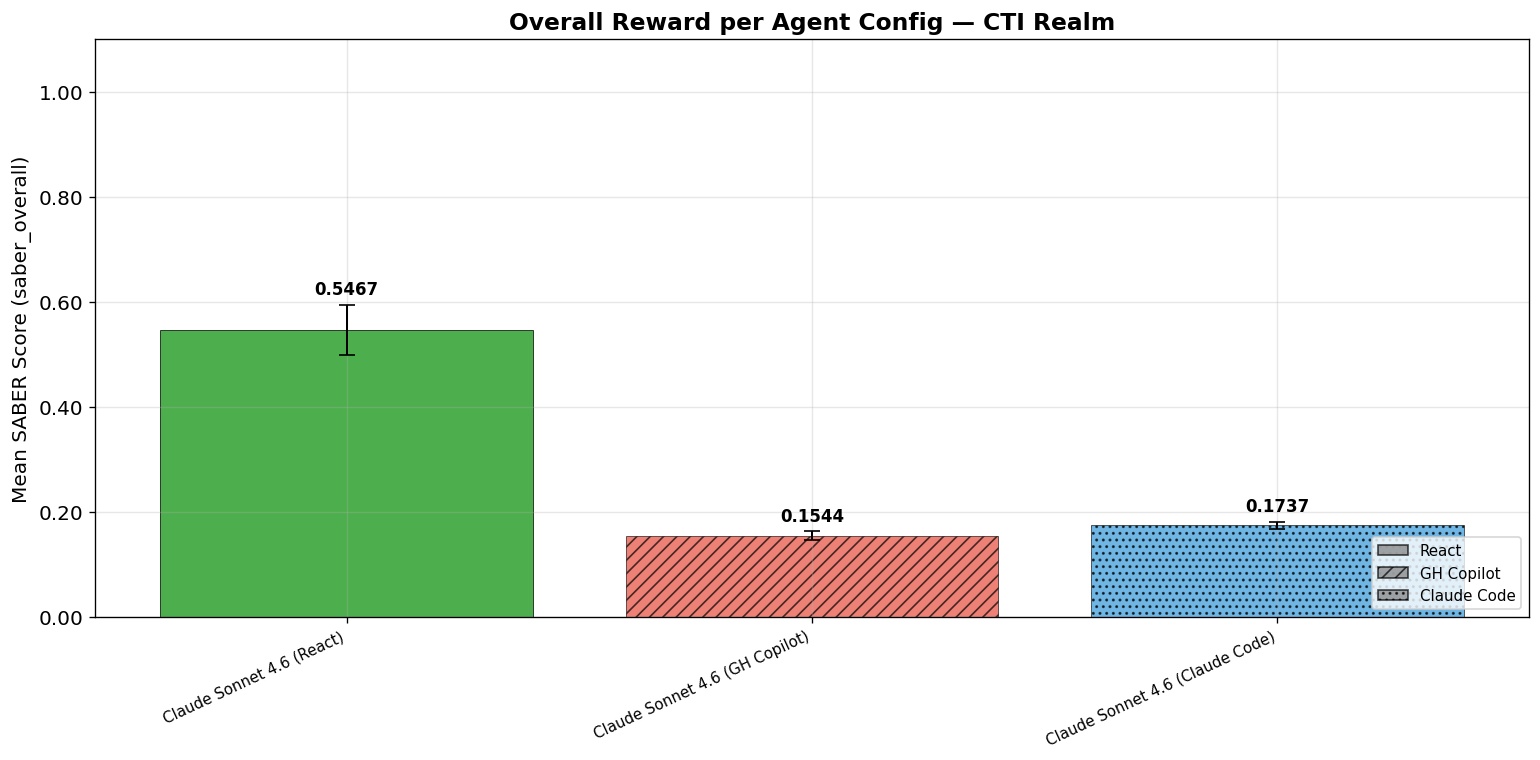


Agent Architecture Summary
  React            avg score = 0.5467  (across 1 models)
  GH Copilot       avg score = 0.1544  (across 1 models)
  Claude Code      avg score = 0.1737  (across 1 models)


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 1: Overall mean scores — grouped by agent architecture
# ══════════════════════════════════════════════════════════════════════════════
active_configs = [m for m in MODEL_ORDER if m in model_overall]

fig, ax = plt.subplots(figsize=(max(13, len(active_configs) * 1.5), 6.5))
means = [overall_df.loc[m, 'mean'] for m in active_configs]
stderrs = [overall_df.loc[m, 'stderr'] for m in active_configs]
colors = [COLORS[m] for m in active_configs]

x = np.arange(len(active_configs))
bars = ax.bar(x, means, color=colors, edgecolor='black', linewidth=0.5, alpha=0.85)

# Add hatching by agent
for i, m in enumerate(active_configs):
    agent = AGENT_OF[m]
    if agent == 'GH Copilot':
        bars[i].set_hatch('///')
        bars[i].set_alpha(0.7)
    elif agent == 'Claude Code':
        bars[i].set_hatch('...')
        bars[i].set_alpha(0.7)

ax.errorbar(x, means, yerr=stderrs, fmt='none', ecolor='black', capsize=5, linewidth=1.2)
for i, (mean, se) in enumerate(zip(means, stderrs)):
    ax.text(i, mean + se + 0.012, f'{mean:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(active_configs, fontsize=9, rotation=25, ha='right')
ax.set_ylabel('Mean SABER Score (saber_overall)')
ax.set_title(f'Overall Reward per Agent Config — {DOMAIN_NAME}', fontweight='bold')
ax.set_ylim(0, 1.10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

# Legend by agent
agent_handles = []
for agent, color in AGENT_COLORS.items():
    if agent in AGENT_EVAL_LOGS:
        h = '' if agent == 'React' else ('///' if agent == 'GH Copilot' else '...')
        agent_handles.append(mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.7,
                                            hatch=h, label=agent))
ax.legend(handles=agent_handles, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'overall_reward_by_agent.png', bbox_inches='tight')
plt.show()

# Agent-level summary
print('\nAgent Architecture Summary')
for agent in AGENT_NAMES:
    agent_configs = [f'{m} ({agent})' for m in AGENT_EVAL_LOGS[agent] if f'{m} ({agent})' in model_overall]
    if agent_configs:
        agent_mean = np.mean([model_overall[c]['mean'] for c in agent_configs])
        print(f'  {agent:15s}  avg score = {agent_mean:.4f}  (across {len(agent_configs)} models)')


---

## 2. Per-Scenario Breakdown *(CTI Realm-Specific)*

### What this measures

Scores broken down by the **8 security incidents** for each agent configuration. This reveals whether agent architecture advantages are **consistent across all incidents** or concentrated in specific task categories.

### How to read the chart

- Each cluster = one incident; bars = agent configurations
- Task counts shown below each incident name
- If one agent config dominates across all incidents, it has a general advantage
- If advantages shift between incidents, the agent architecture effect is task-dependent

### Key question

Do agent architecture effects vary by incident type? An architecture that excels at data exfiltration but struggles with insider threats tells a different story than one that uniformly outperforms.

### Key insights (CTI Realm)

> _Run the cells above and analyze the results to fill in domain-specific insights._

Per-Platform Mean Scores
model  Claude Sonnet 4.6 (React)  Claude Sonnet 4.6 (GH Copilot)  Claude Sonnet 4.6 (Claude Code)
group                                                                                            
aks                       0.4716                          0.1672                           0.1839
cloud                     0.3008                          0.0852                           0.1204
linux                     0.6423                          0.1678                           0.1839


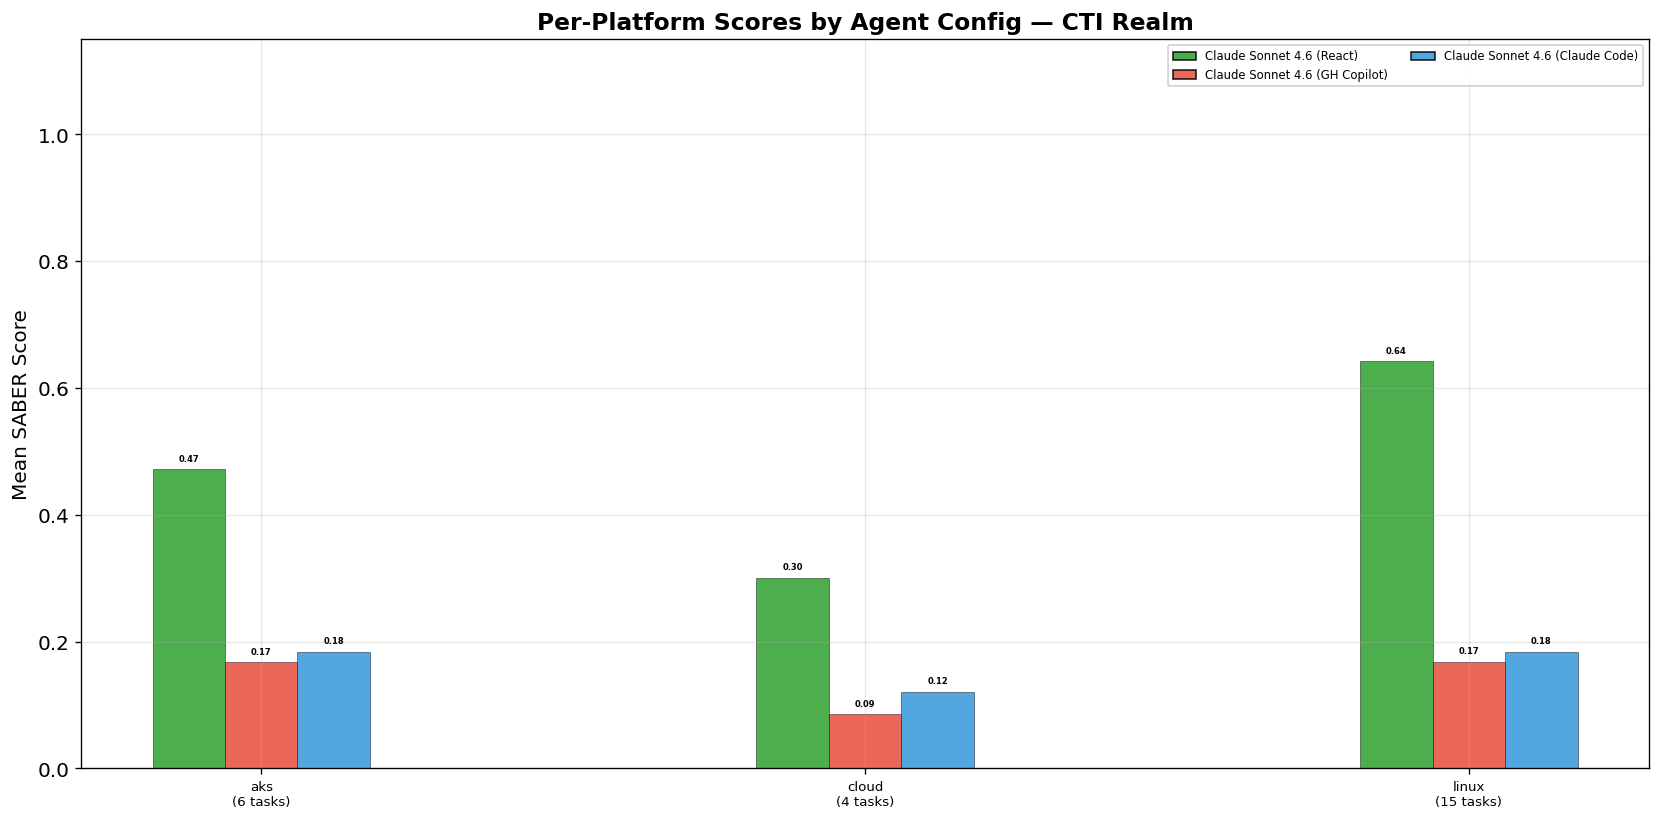

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 2: Per-group breakdown
# ══════════════════════════════════════════════════════════════════════════════
if GROUP_FN is None:
    print('Per-group analysis skipped (GROUP_FN is None)')
else:
    active_configs = [m for m in MODEL_ORDER if m in model_overall]
    group_scores = samples_df.groupby(['group', 'model'])['score'].mean().unstack('model').reindex(columns=active_configs)
    group_scores = group_scores.sort_index()
    group_counts = samples_df[samples_df['model'] == active_configs[0]].groupby('group').size()

    print(f'Per-{GROUP_LABEL} Mean Scores')
    print(group_scores.round(4).to_string())

    fig, ax = plt.subplots(figsize=(max(14, len(group_scores) * 2.5), 7))
    n_groups = len(group_scores)
    n_configs = len(active_configs)
    bar_width = min(0.12, 0.85 / n_configs)
    xg = np.arange(n_groups)

    for i, config in enumerate(active_configs):
        if config not in group_scores.columns:
            continue
        offset = (i - n_configs/2 + 0.5) * bar_width
        vals = group_scores[config].values
        ax.bar(xg + offset, vals, bar_width, color=COLORS[config],
               edgecolor='black', linewidth=0.3, alpha=0.85)
        for xi, v in zip(xg, vals):
            if not np.isnan(v):
                ax.text(xi + offset, v + 0.01, f'{v:.2f}', ha='center', va='bottom',
                        fontsize=5, fontweight='bold')

    handles = [mpatches.Patch(facecolor=COLORS[m], edgecolor='black', alpha=0.85, label=m) for m in active_configs]
    ax.legend(handles=handles, loc='upper right', fontsize=7, framealpha=0.9, ncol=2)

    ax.set_xticks(xg)
    labels = [f'{grp}\n({group_counts.get(grp, "?")} tasks)' for grp in group_scores.index]
    ax.set_xticklabels(labels, rotation=0, ha='center', fontsize=8)
    ax.set_ylabel('Mean SABER Score')
    ax.set_title(f'Per-{GROUP_LABEL} Scores by Agent Config — {DOMAIN_NAME}', fontweight='bold')
    ax.set_ylim(0, 1.15)
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / f'per_{GROUP_LABEL.lower()}_scores_by_agent.png', bbox_inches='tight')
    plt.show()


---

## 3. Cost Analysis

### What this measures

Quantifies **total cost**, **cost per sample**, and **score-cost tradeoffs** for each agent configuration using token counts from eval logs and published API pricing.

### Charts

1. **Total Eval Cost** — absolute dollar cost of the full benchmark run per agent config
2. **Cost per Sample** — average cost per task (useful for budgeting)
3. **Score vs. Cost (Pareto)** — upper-left is best value; shows the cost-performance frontier across architectures

### Key question

Do some agent architectures cost more due to longer conversations, more retries, or more verbose prompts? A more expensive architecture is only justified if it produces meaningfully higher scores.

### What to look for

- **Same model, different cost** indicates the agent architecture induces different conversation lengths
- **Higher cost without higher score** = the architecture is inefficient (wasting tokens on retries or verbose system prompts)
- Points in the **upper-left** of the Pareto chart represent the best value configurations

> **To add pricing for your model:** Update `PRICING` in the Configuration cell.

### Key insights (CTI Realm)

> _Run the cells above and analyze the results to fill in domain-specific insights._

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 3a: Cost extraction
# ══════════════════════════════════════════════════════════════════════════════
cost_df = pd.DataFrame(extract_cost_rows(EVAL_LOGS, LOG_DIR, PRICING, N_SAMPLES)).set_index('model')
active_cost = [m for m in MODEL_ORDER if m in cost_df.index]
cost_df = cost_df.reindex(active_cost)

print('Cost Breakdown per Agent Config')
print(cost_df[['score', 'total_cost', 'cost_per_sample']].round(2).to_string())
print()
print('Token Usage per Agent Config')
token_cols = ['input_tokens', 'output_tokens', 'cache_read', 'cache_write', 'reasoning_tokens', 'total_tokens']
avail_cols = [c for c in token_cols if c in cost_df.columns]
print(cost_df[avail_cols].to_string())


Cost Breakdown per Agent Config
                                 score  total_cost  cost_per_sample
model                                                              
Claude Sonnet 4.6 (React)         0.55        8.99             0.36
Claude Sonnet 4.6 (GH Copilot)    0.15        7.64             0.31
Claude Sonnet 4.6 (Claude Code)   0.17       10.75             0.43

Token Usage per Agent Config
                                 input_tokens  output_tokens  cache_read  cache_write  reasoning_tokens  total_tokens
model                                                                                                                
Claude Sonnet 4.6 (React)                 248         204728     4902431      1089228                 0       6196635
Claude Sonnet 4.6 (GH Copilot)          88327         188909     4046290       805488             18668       5129014
Claude Sonnet 4.6 (Claude Code)           318         190849     9204855      1183131                 0      10579153


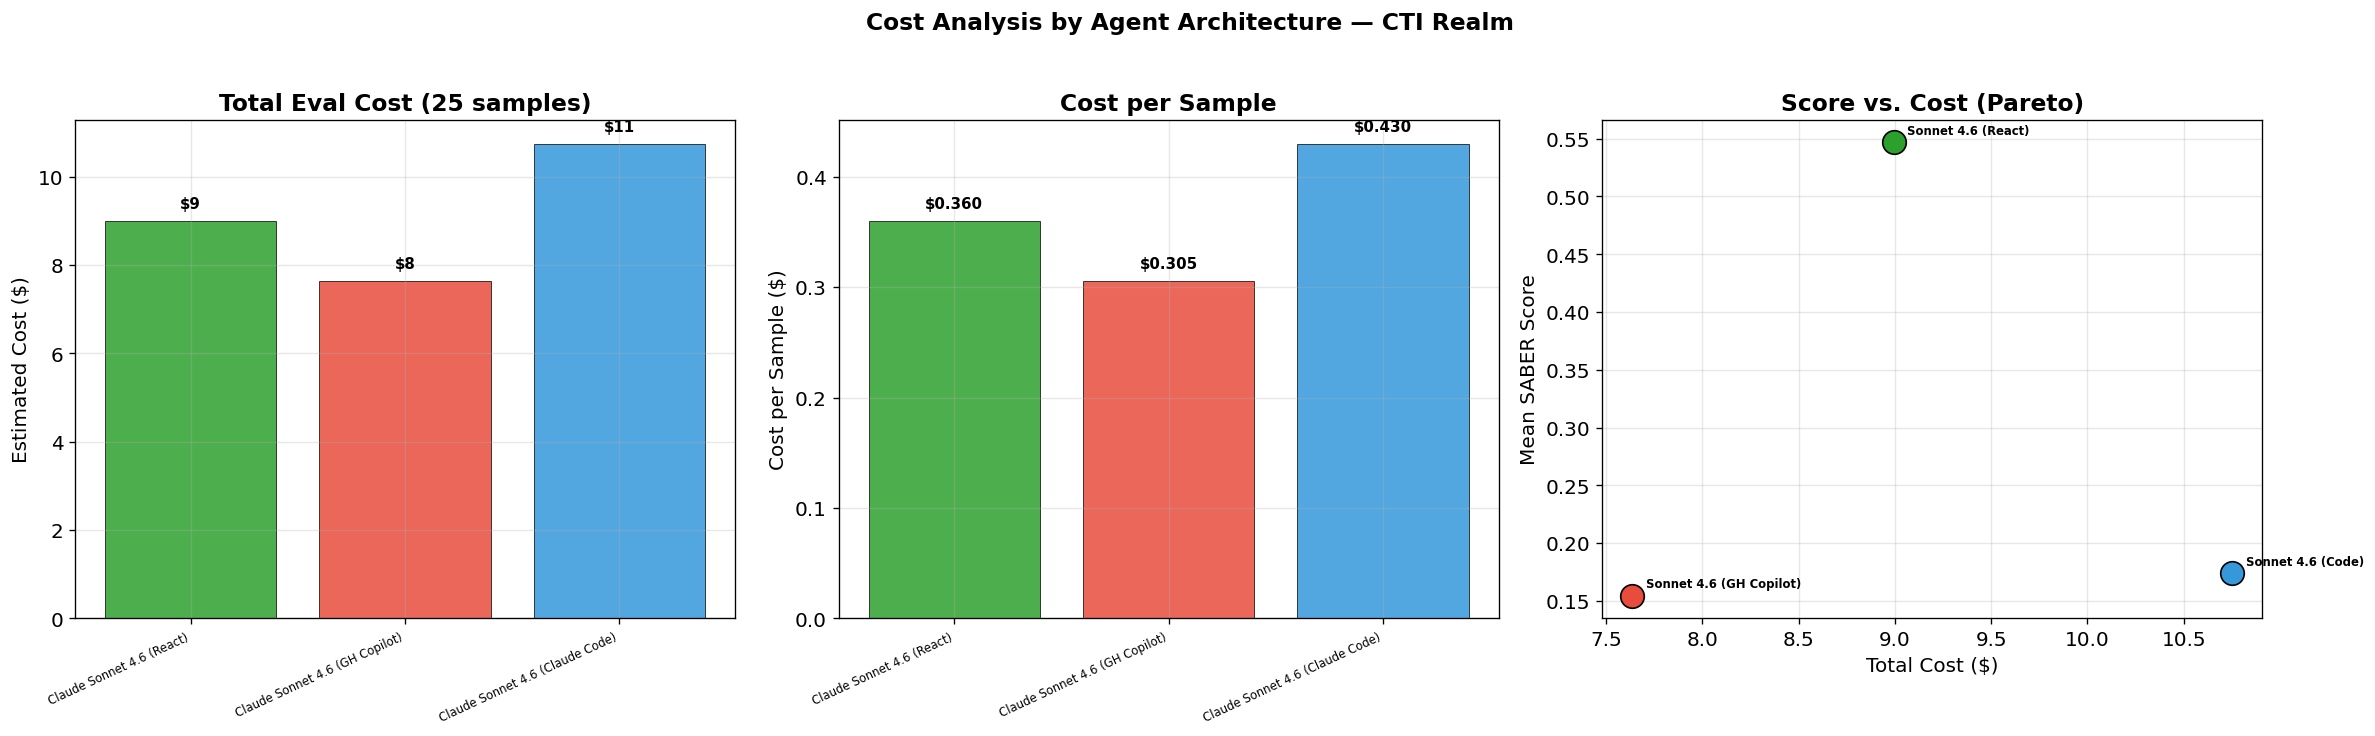

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 3b: Cost visualization
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
x = np.arange(len(active_cost))

# Panel 1: Total cost
ax = axes[0]
for i, m in enumerate(active_cost):
    tc = cost_df.loc[m, 'total_cost']
    ax.bar(i, tc, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, tc + cost_df['total_cost'].max()*0.02, f'${tc:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(active_cost, fontsize=7, rotation=25, ha='right')
ax.set_ylabel('Estimated Cost ($)'); ax.set_title(f'Total Eval Cost ({N_SAMPLES} samples)', fontweight='bold')

# Panel 2: Cost per sample
ax = axes[1]
for i, m in enumerate(active_cost):
    cps = cost_df.loc[m, 'cost_per_sample']
    ax.bar(i, cps, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, cps + cost_df['cost_per_sample'].max()*0.02, f'${cps:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(active_cost, fontsize=7, rotation=25, ha='right')
ax.set_ylabel('Cost per Sample ($)'); ax.set_title('Cost per Sample', fontweight='bold')

# Panel 3: Pareto
ax = axes[2]
for m in active_cost:
    row = cost_df.loc[m]
    ax.scatter(row['total_cost'], row['score'], s=200, color=COLORS[m], edgecolor='black', linewidth=1, zorder=5)
    short = m.replace('Claude ', '').replace('GPT-', 'GPT')
    ax.annotate(short, (row['total_cost'], row['score']), textcoords='offset points', xytext=(8, 5), fontsize=7, fontweight='bold')
ax.set_xlabel('Total Cost ($)'); ax.set_ylabel('Mean SABER Score'); ax.set_title('Score vs. Cost (Pareto)', fontweight='bold')

fig.suptitle(f'Cost Analysis by Agent Architecture — {DOMAIN_NAME}', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'cost_analysis_by_agent.png', bbox_inches='tight')
plt.show()


---

## 4. Token Usage Breakdown

### What this measures

Decomposes **where tokens are spent** for each agent configuration: input, output, cache reads/writes, and reasoning tokens.

- **Input** — prompts, system messages, tool results, conversation history
- **Output** — model-generated text, tool calls, answers
- **Cache Read/Write** — prompt caching (reduces cost for repeated prefixes)
- **Reasoning** — internal chain-of-thought (extended thinking)

### How to read the chart

- Horizontal stacked bars show the token composition per agent config
- Longer bars = more tokens consumed overall
- Different architectures may produce dramatically different input/output ratios due to system prompt verbosity or conversation management

### Key question

Do agent architectures differ primarily in input tokens (system prompt overhead), output tokens (model verbosity), or reasoning tokens (thinking depth)? This reveals the structural cost drivers of each architecture.

### Key insights (CTI Realm)

> _Run the cells above and analyze the results to fill in domain-specific insights._

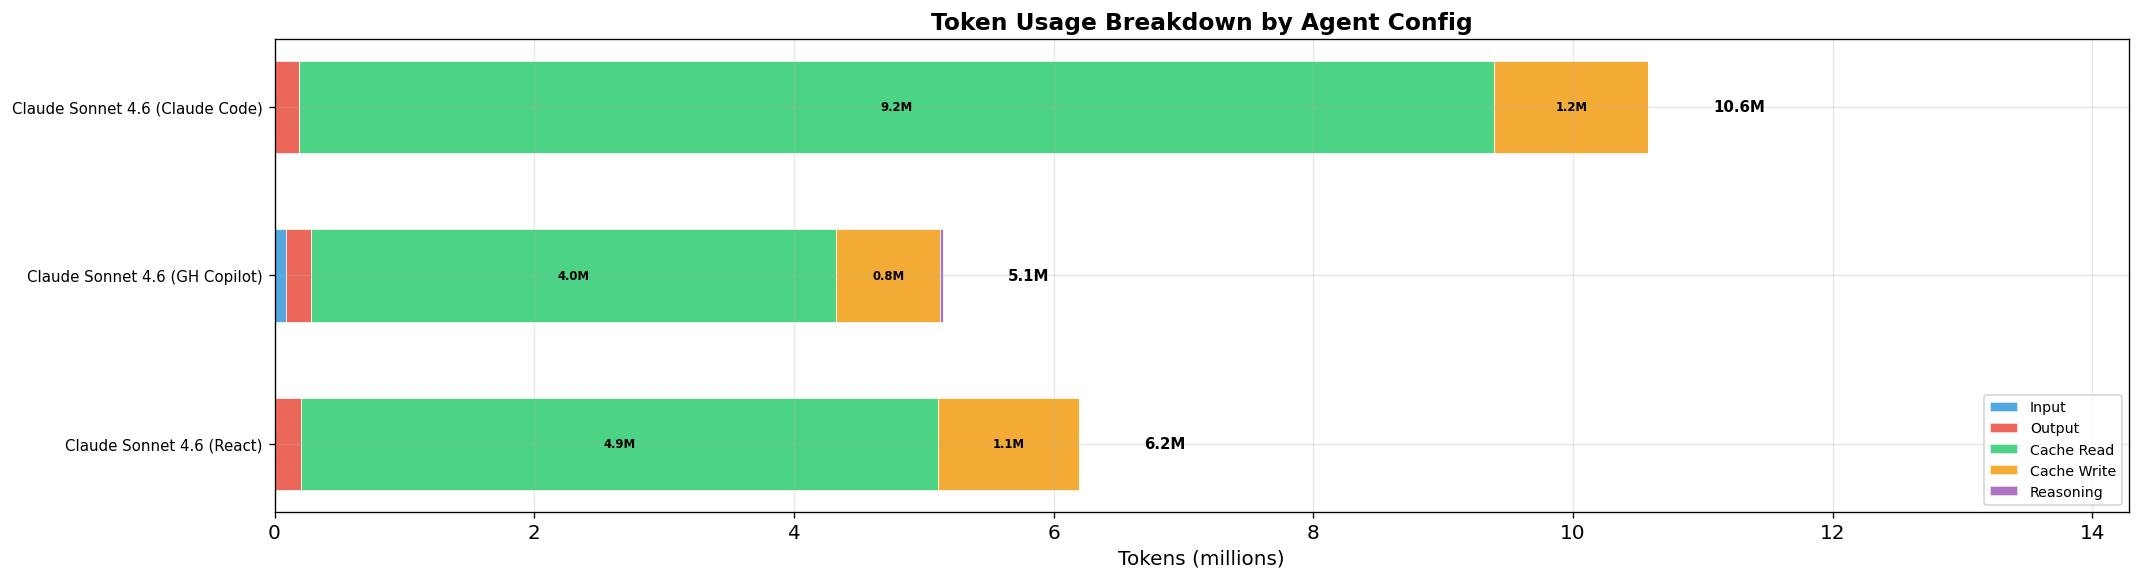

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 4: Token usage stacked horizontal bars
# ══════════════════════════════════════════════════════════════════════════════
categories = ['Input', 'Output', 'Cache Read', 'Cache Write', 'Reasoning']
cat_colors = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12', '#9B59B6']
token_keys = ['input_tokens', 'output_tokens', 'cache_read', 'cache_write', 'reasoning_tokens']

fig, ax = plt.subplots(figsize=(18, max(5, len(active_cost) * 1.2)))
bar_height = 0.55
all_totals = []
for m in active_cost:
    total = sum(cost_df.loc[m].get(k, 0)/1e6 for k in token_keys)
    all_totals.append(total)
global_max = max(all_totals) if all_totals else 1

for i, m in enumerate(active_cost):
    row = cost_df.loc[m]
    vals = [row.get(k, 0)/1e6 for k in token_keys]
    left = 0
    for j, (v, c) in enumerate(zip(vals, cat_colors)):
        ax.barh(i, v, left=left, height=bar_height, color=c, edgecolor='white',
                linewidth=0.5, alpha=0.85, label=categories[j] if i == 0 else '')
        if v >= global_max * 0.05:
            ax.text(left + v/2, i, f'{v:.1f}M', ha='center', va='center', fontsize=7, fontweight='bold')
        left += v
    ax.text(left + 0.5, i, f'{sum(vals):.1f}M', va='center', ha='left', fontsize=9, fontweight='bold')

ax.set_yticks(range(len(active_cost))); ax.set_yticklabels(active_cost, fontsize=9)
ax.set_xlabel('Tokens (millions)'); ax.set_title('Token Usage Breakdown by Agent Config', fontweight='bold')
ax.set_xlim(right=global_max * 1.35)

legend_handles = [mpatches.Patch(facecolor=c, edgecolor='white', alpha=0.85, label=cat) for cat, c in zip(categories, cat_colors)]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8.5)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'token_usage_by_agent.png', bbox_inches='tight')
plt.show()


---

## 5. Cost Efficiency: Reward per Dollar

$$\text{Cost Efficiency} = \frac{\text{Mean SABER Score}}{\text{Total Cost (\$)}}$$

### What this measures

Higher = better value for money. The most cost-efficient agent configuration is not always the highest-scoring one — it's the one that delivers the most score per dollar spent.

### Key question

For the same model, does a cheaper agent architecture deliver comparable scores? If React costs half as much as Copilot but scores within 1%, React is clearly the better choice for production. Conversely, a more expensive architecture that unlocks meaningfully higher scores may be worth the premium.

### What to look for

- **Same model, different efficiency** = agent architecture directly impacts cost-effectiveness
- The highest-scoring config may not be the most efficient if it costs disproportionately more

### Key insights (CTI Realm)

> _Run the cells above and analyze the results to fill in domain-specific insights._

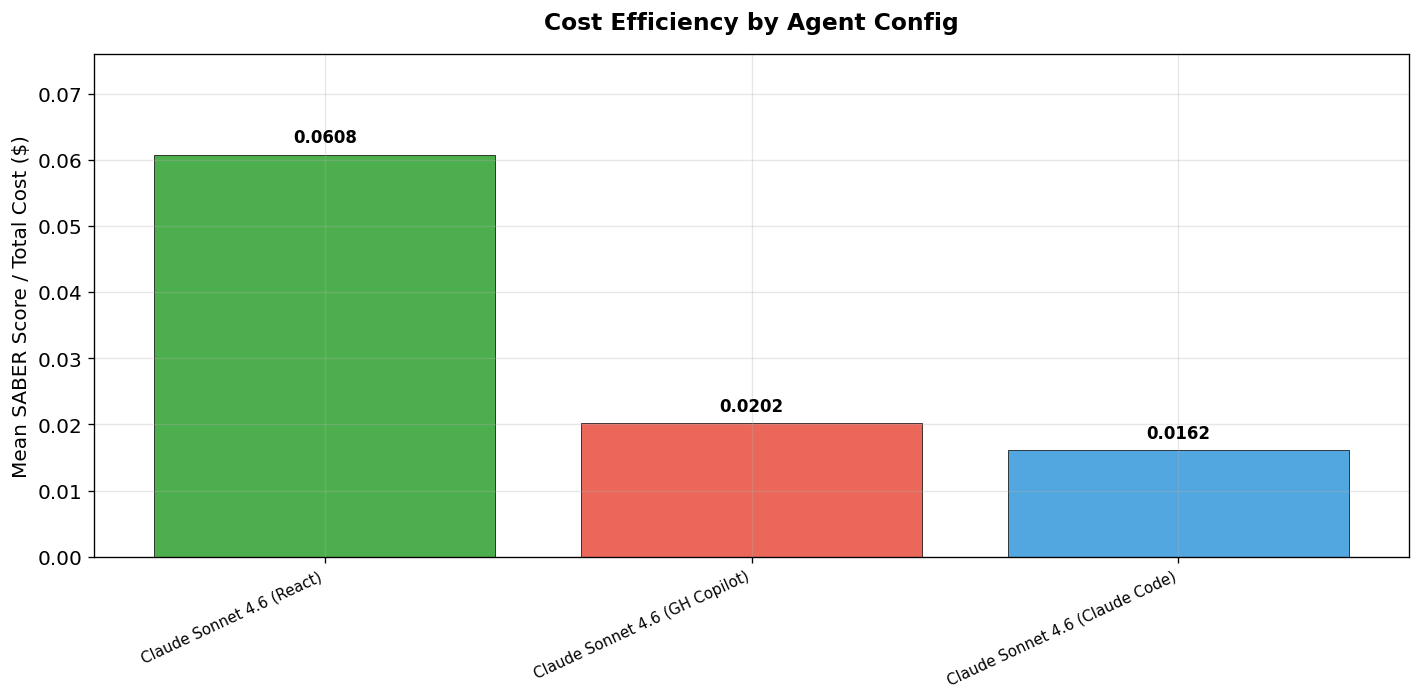

Cost Efficiency Summary
Config                               Score     Cost   $/sample    Score/$
---------------------------------------------------------------------------
Claude Sonnet 4.6 (React)            0.547 $   8.99 $   0.3598    0.06078
Claude Sonnet 4.6 (GH Copilot)       0.154 $   7.64 $   0.3055    0.02022
Claude Sonnet 4.6 (Claude Code)      0.174 $  10.75 $   0.4301    0.01616


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 5: Cost efficiency — reward per dollar
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(max(12, len(active_cost) * 1.5), 6))
reward_per_dollar = cost_df['score'] / cost_df['total_cost']

for i, m in enumerate(active_cost):
    rpd = reward_per_dollar[m]
    ax.bar(i, rpd, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, rpd + reward_per_dollar.max()*0.02, f'{rpd:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_xticks(range(len(active_cost)))
ax.set_xticklabels(active_cost, fontsize=9, rotation=25, ha='right')
ax.set_ylabel('Mean SABER Score / Total Cost ($)')
ax.set_title('Cost Efficiency by Agent Config', fontweight='bold', pad=15)
ax.set_ylim(0, reward_per_dollar.max() * 1.25)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'cost_efficiency_by_agent.png', bbox_inches='tight')
plt.show()

print('Cost Efficiency Summary')
print(f'{"Config":35s} {"Score":>6s} {"Cost":>8s} {"$/sample":>10s} {"Score/$":>10s}')
print('-' * 75)
for m in active_cost:
    row = cost_df.loc[m]
    rpd = row['score'] / row['total_cost']
    print(f'{m:35s} {row["score"]:6.3f} ${row["total_cost"]:7.2f} ${row["cost_per_sample"]:9.4f} {rpd:10.5f}')


---

## 6. Sub-Task Score Breakdown

### What this measures

Each task produces three score types:
- **Submission** — final answer correctness (LLM-judge or static match)
- **Checkpoints** — intermediate investigative steps (varies by task in CTI Realm)
- **Aggregate** — weighted combination feeding into `saber_overall`

### How to read the chart

- Grouped bars per agent config: blue = Submission, orange = Checkpoints, green = Aggregate
- A config with high submission but low checkpoints may be "guessing" — risky for production
- A config with high checkpoints but low submission investigates well but fails to synthesize

### Key question

Do agent architectures affect investigation thoroughness (checkpoints) vs. answer quality (submission) differently? An architecture that boosts checkpoints more than submission produces more trustworthy agents for real-world deployment.

### Key insights (CTI Realm)

> _Run the cells above and analyze the results to fill in domain-specific insights._  - Claude Haiku 4.5 (React): submission=0.679, checkpoint=0.203, aggregate=0.838
  - Claude Sonnet 4.6 (React): submission=0.705, checkpoint=0.196, aggregate=0.857
  - Claude Opus 4.6 (React): submission=0.756, checkpoint=0.183, aggregate=0.865
  - GPT-5.4 (React): submission=0.683, checkpoint=0.224, aggregate=0.875
  - Claude Sonnet 4.6 (GH Copilot): submission=0.693, checkpoint=0.161, aggregate=0.791
  - Claude Opus 4.6 (GH Copilot): submission=0.738, checkpoint=0.170, aggregate=0.840

Sub-Task Mean Scores
category                         Checkpoints  Aggregate
model                                                  
Claude Sonnet 4.6 (React)             1.0934     0.5467
Claude Sonnet 4.6 (GH Copilot)        0.3089     0.1544
Claude Sonnet 4.6 (Claude Code)       0.3475     0.1737


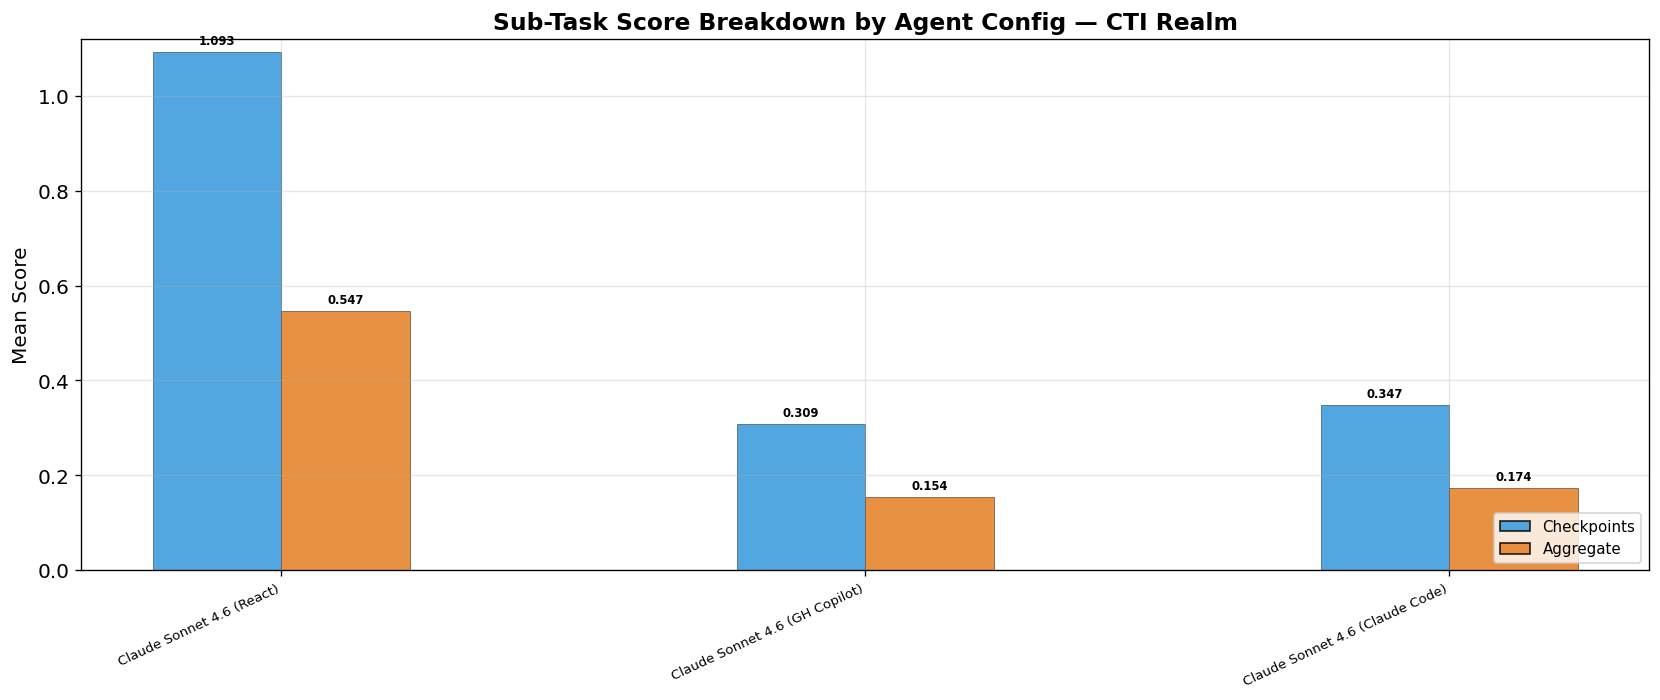

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 6: Sub-task breakdown
# ══════════════════════════════════════════════════════════════════════════════
subtasks_df['category'] = subtasks_df['score_type'].apply(classify_score_type)
active_configs = [m for m in MODEL_ORDER if m in model_overall]
cat_means = subtasks_df.groupby(['model', 'category'])['score'].mean().unstack('category')
available_cats = [c for c in ['Submission', 'Checkpoints', 'Aggregate'] if c in cat_means.columns]
cat_means = cat_means.reindex(active_configs)[available_cats]

print('Sub-Task Mean Scores')
print(cat_means.round(4).to_string())

fig, ax = plt.subplots(figsize=(max(14, len(active_configs) * 1.5), 6))
cat_plot_colors = ['#3498DB', '#E67E22', '#2ECC71'][:len(available_cats)]
x = np.arange(len(active_configs))
bar_width = min(0.22, 0.8 / len(available_cats))

for j, (cat, color) in enumerate(zip(available_cats, cat_plot_colors)):
    offset = (j - len(available_cats)/2 + 0.5) * bar_width
    vals = []
    for m in active_configs:
        vals.append(cat_means.loc[m, cat] if m in cat_means.index else 0)
    ax.bar(x + offset, vals, bar_width, color=color, edgecolor='black', linewidth=0.3, alpha=0.85)
    for i, v in enumerate(vals):
        ax.text(x[i] + offset, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

cat_handles = [mpatches.Patch(facecolor=c, edgecolor='black', alpha=0.85, label=cat) for cat, c in zip(available_cats, cat_plot_colors)]
ax.legend(handles=cat_handles, fontsize=9, loc='lower right')
ax.set_xticks(x); ax.set_xticklabels(active_configs, fontsize=8, rotation=25, ha='right')
ax.set_ylabel('Mean Score')
ax.set_title(f'Sub-Task Score Breakdown by Agent Config — {DOMAIN_NAME}', fontweight='bold')
ax.set_ylim(0, 1.12)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'subtask_breakdown_by_agent.png', bbox_inches='tight')
plt.show()


---

## 7. Checkpoint Score Distributions

### What this measures

Violin plots showing the **full distribution** of checkpoint scores for each agent configuration. Wide regions = many samples clustered at that score level.

### How to read the chart

- **Bimodal distributions** (two peaks at 0 and 1) = agent either nails the checkpoint or misses completely
- **Tight distributions** = consistent performance across tasks
- **Wide, flat distributions** = highly variable — some tasks pass, others fail unpredictably
- Mean (μ) and sample count (n) annotated above each violin

### Key question

Do agent architectures produce different checkpoint score distributions? An architecture with a more uniform distribution (fewer zeros) may be more reliable for real-world use, even if its mean is slightly lower.

### Key insights (CTI Realm)

- **React** has a dramatically wider distribution (range 0–6.5, μ=1.093) compared to GH Copilot (μ=0.309) and Claude Code (μ=0.347) — React earns high checkpoint scores on some tasks while the other architectures cluster near zero
- React shows a **long upper tail** reaching 6.0+ (C4 detection quality scores), while GH Copilot and Claude Code rarely exceed 1.5 — React is the only architecture that achieves meaningful detection quality
- GH Copilot and Claude Code distributions are **heavily zero-concentrated** with a small cluster around 0.75–1.25 (likely C1 MITRE technique credit) — they achieve only the easiest checkpoints
- All architectures show 125 checkpoint observations per config (5 checkpoints × 25 samples), confirming complete data coverage

> **Note:** The code cell uses `classify_score_type()` instead of `str.startswith('checkpoint')` to handle CTI Realm's `c0_*`/`c1_*` naming convention. TODO: Update the domain-agnostic template to use `classify_score_type()` consistently.

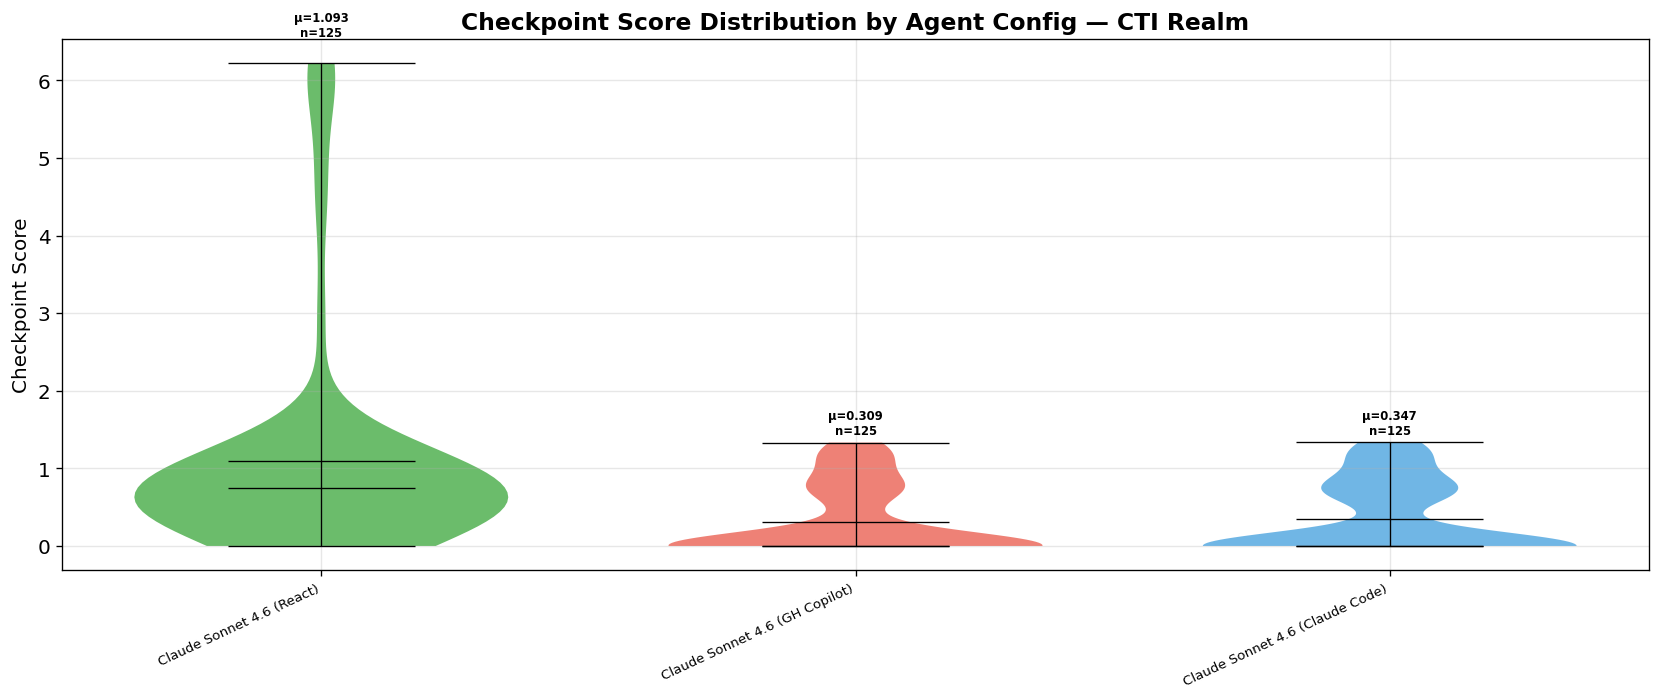

In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 7: Checkpoint score distributions (violin)
# ══════════════════════════════════════════════════════════════════════════════
# NOTE: CTI Realm uses c0_*, c1_*, ... checkpoint names instead of checkpoint_*.
# TODO: Update domain-agnostic template to use classify_score_type() consistently
#       instead of hardcoding str.startswith('checkpoint').
checkpoint_df = subtasks_df[subtasks_df['score_type'].apply(classify_score_type) == 'Checkpoints'].copy()
active_configs = [m for m in MODEL_ORDER if m in model_overall]

fig, ax = plt.subplots(figsize=(max(14, len(active_configs) * 1.5), 6))
positions, tick_labels = [], []

for i, config in enumerate(active_configs):
    data = checkpoint_df[checkpoint_df['model'] == config]['score'].values
    if len(data) == 0:
        continue
    vp = ax.violinplot([data], positions=[i], showmeans=True, showmedians=True, widths=0.7)
    for pc in vp['bodies']:
        pc.set_facecolor(COLORS[config])
        pc.set_alpha(0.7)
    for part in ('cmaxes', 'cmins', 'cbars', 'cmeans', 'cmedians'):
        if part in vp:
            vp[part].set_edgecolor('black')
            vp[part].set_linewidth(0.8)
    ax.text(i, data.max() + data.max() * 0.05, f'μ={np.mean(data):.3f}\nn={len(data)}', ha='center', va='bottom', fontsize=7, fontweight='bold')
    positions.append(i)
    tick_labels.append(config)

ax.set_xticks(positions); ax.set_xticklabels(tick_labels, fontsize=8, rotation=25, ha='right')
ax.set_ylabel('Checkpoint Score')
ax.set_title(f'Checkpoint Score Distribution by Agent Config — {DOMAIN_NAME}', fontweight='bold')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'checkpoint_distributions_by_agent.png', bbox_inches='tight')
plt.show()

---

## 8. Agent Trajectory Analysis

### What this measures

Analyses 8a–8b examine **behavioral patterns** of the agent — how many steps it takes, which tools it uses, and how efficiently it spends its tool-call budget.

This cell loads per-sample trajectory data: steps (assistant turns), tool calls, and timing from each eval log using inspect_ai's typed log API.

### Key metrics loaded

- **n_tool_calls** — actual tool invocations (capped at `TOOL_CALL_LIMIT` in practice)
- **n_steps** — assistant message turns (can exceed tool call limit since some turns don't use tools)
- **tool_counts** — per-tool breakdown (e.g., bash vs. python)
- **total_time** — wall-clock seconds per sample

### Key question

Do agent architectures induce different tool-calling behaviors? An architecture that uses fewer tool calls for the same score is more efficient. An architecture that causes the model to max out its tool-call budget more often may be contributing to lower scores through budget exhaustion.

### Key insights (CTI Realm)

> _Run the cells above and analyze the results to fill in domain-specific insights._

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# TRAJECTORY DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════
from collections import Counter

traj_df = load_trajectory_data(EVAL_LOGS, LOG_DIR, MODEL_ORDER, group_fn=GROUP_FN)

# Normalize tool names to lowercase (e.g. "Bash" and "bash" → "bash")
traj_df['tool_counts'] = traj_df['tool_counts'].apply(
    lambda d: dict(Counter({k.lower(): v for k, v in d.items()}))
)

all_tools = sorted({t for tc in traj_df['tool_counts'] for t in tc})
for tool in all_tools:
    traj_df[f'tool_{tool}'] = traj_df['tool_counts'].apply(lambda d, t=tool: d.get(t, 0))

active_traj = [m for m in MODEL_ORDER if m in traj_df['model'].unique()]

print(f'Loaded trajectory data: {len(traj_df)} samples x {traj_df["model"].nunique()} configs')
print(f'  Tools observed: {all_tools}')
print()
for m in active_traj:
    mdf = traj_df[traj_df['model'] == m]
    print(f'  {m:35s}  steps={mdf.n_steps.mean():.1f}  tool_calls={mdf.n_tool_calls.mean():.1f}  time={mdf.total_time.mean():.0f}s')

Loaded trajectory data: 75 samples x 3 configs
  Tools observed: ['bash', 'execute_kql_query', 'get_cti_reports_by_tag', 'get_table_schema', 'grep', 'list_cti_report_tags', 'list_kusto_tables', 'mcp__saber_tools__execute_kql_query', 'mcp__saber_tools__get_cti_reports_by_tag', 'mcp__saber_tools__get_table_schema', 'mcp__saber_tools__list_cti_report_tags', 'mcp__saber_tools__list_kusto_tables', 'mcp__saber_tools__sample_table_data', 'mcp__saber_tools__search_mitre_techniques', 'mcp__saber_tools__search_sigma_rules', 'mcp__saber_tools__validate_output_json', 'read', 'report_intent', 'saber_tools-execute_kql_query', 'saber_tools-get_cti_reports_by_tag', 'saber_tools-get_table_schema', 'saber_tools-list_cti_report_tags', 'saber_tools-list_kusto_tables', 'saber_tools-sample_table_data', 'saber_tools-search_mitre_techniques', 'saber_tools-search_sigma_rules', 'saber_tools-validate_output_json', 'sample_table_data', 'search_mitre_techniques', 'search_sigma_rules', 'validate_output_json']

  Cl

### 8a. Mean Score vs. Tool-Call Limit — What's the Optimal Budget?

### What this measures

For each tool-call limit N on the x-axis, compute the mean score across **all samples**, where samples that needed > N tool calls get score 0 (wouldn't have finished under that budget). This shows where returns from allowing more tool calls diminish **and whether agent architecture affects this curve**.

### How to read the chart

- **Steeper early rise** = agent config solves many tasks quickly (efficient)
- **Plateau** = increasing the budget further yields diminishing returns
- Curves converge to each config's actual mean score at the real tool-call cap
- **Left panel** = overall score; **Right panel** = checkpoint score

### Key question

Do some agent architectures reach their peak performance with fewer tool calls? An architecture that converges earlier is more budget-efficient and would benefit less from increasing the tool-call limit.

### Key insights (CTI Realm)

> _Run the cells above and analyze the results to fill in domain-specific insights._

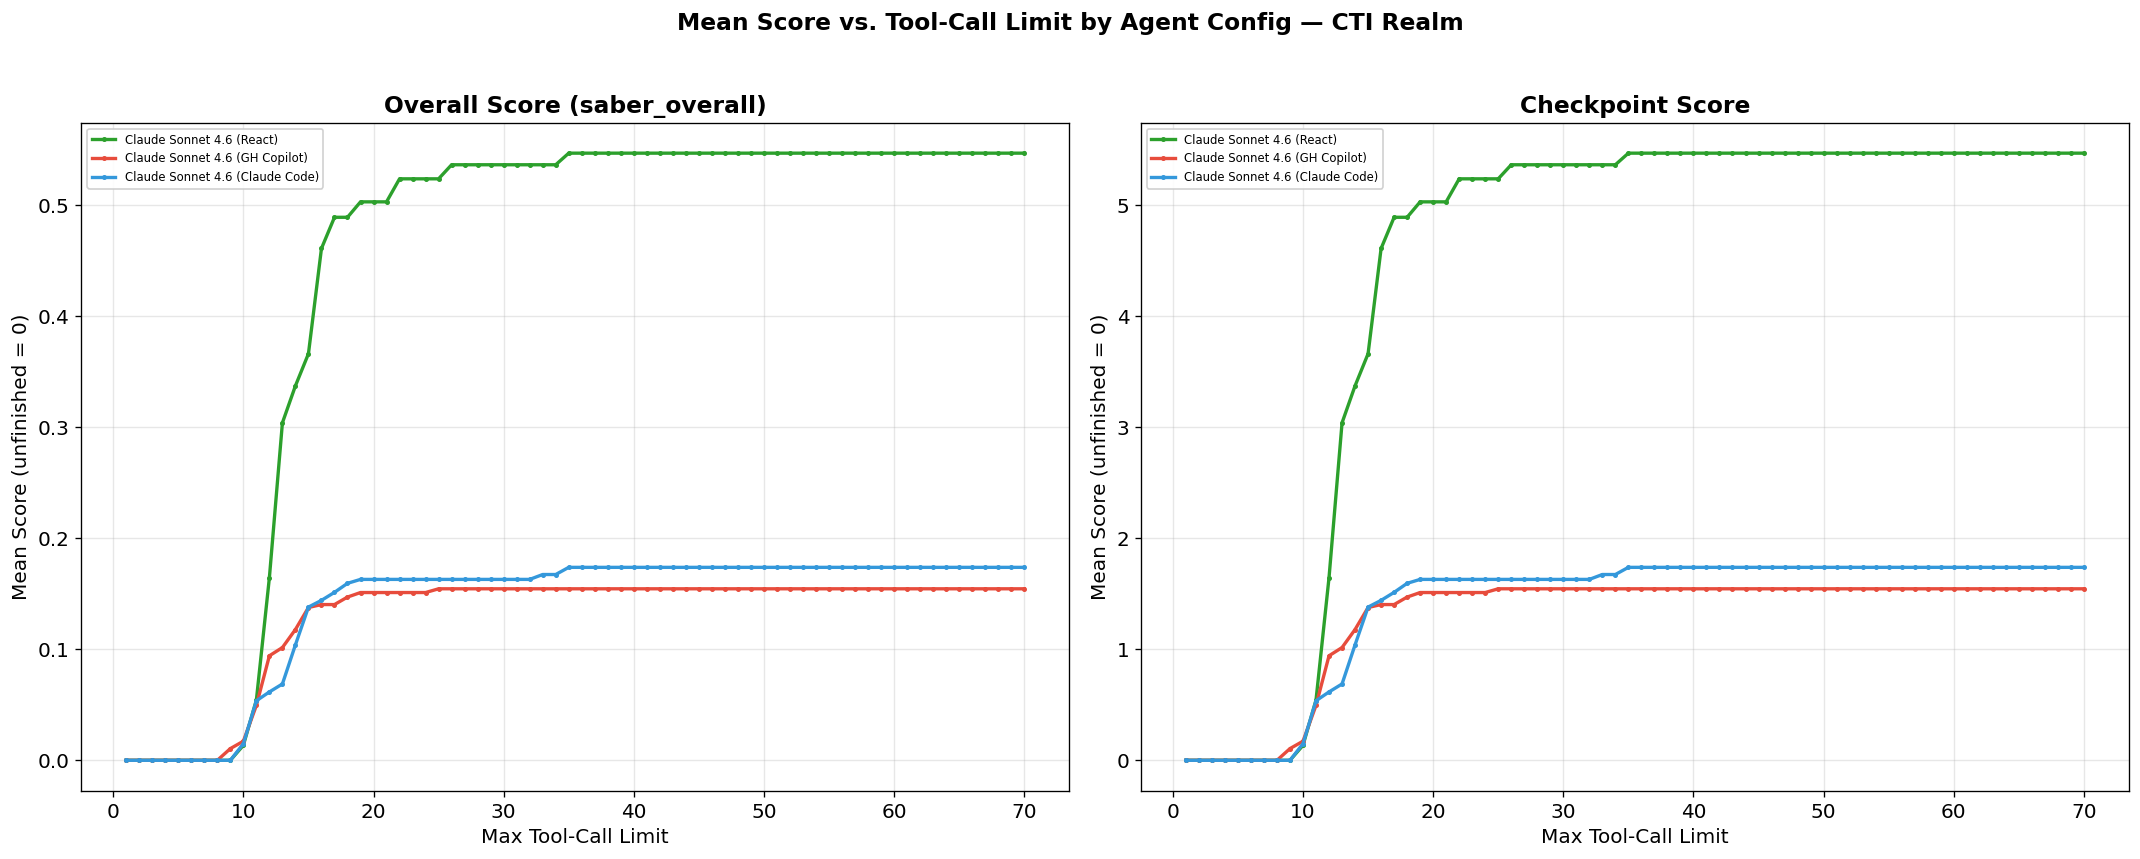

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 8a: Score vs tool-call limit
# ══════════════════════════════════════════════════════════════════════════════
step_lookup = traj_df[['model', 'sample_id', 'n_tool_calls']].copy()
merged = subtasks_df.merge(step_lookup, on=['model', 'sample_id'], how='inner')
if 'category' not in merged.columns:
    merged['category'] = merged['score_type'].apply(classify_score_type)

call_limits = list(range(1, TOOL_CALL_LIMIT + 1))

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)

for ax, (score_label, score_src) in zip(axes, [
    ('Overall Score (saber_overall)', 'overall'),
    ('Checkpoint Score', 'checkpoint'),
]):
    for m in active_traj:
        if score_src == 'overall':
            mdf = traj_df[traj_df['model'] == m].copy()
            total_samples = len(mdf)
        else:
            mdf = merged[(merged['model'] == m) & (merged['category'] == 'Checkpoints')].copy()
            if mdf.empty:
                continue
            total_samples = mdf['sample_id'].nunique()

        means = []
        for limit in call_limits:
            completed = mdf[mdf['n_tool_calls'] <= limit]
            avg = completed['score'].sum() / total_samples if total_samples > 0 else 0
            means.append(avg)

        ax.plot(call_limits, means, color=COLORS[m], linewidth=2, marker='o', markersize=2, label=m, zorder=5)

    ax.set_xlabel('Max Tool-Call Limit')
    ax.set_ylabel('Mean Score (unfinished = 0)')
    ax.set_title(score_label, fontweight='bold')
    ax.legend(fontsize=7, loc='best', framealpha=0.9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(f'Mean Score vs. Tool-Call Limit by Agent Config — {DOMAIN_NAME}',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'score_vs_tool_call_limit_by_agent.png', bbox_inches='tight')
plt.show()


### 8b. Effort Distribution per Agent Config

### What this measures

How many tool calls and steps does each agent configuration use per task? Violin plots show the full distribution.

### How to read the chart

- **Narrow, low** = efficient (solves tasks quickly)
- **Wide, high** = variable or struggling (many tasks need lots of calls)
- **Long upper tail** = some tasks cause the agent to max out its tool-call budget
- Mean (μ) annotated above each violin

### Key question

Do agent architectures differ in effort distribution? An architecture that induces fewer tool calls while maintaining the same score delivers better efficiency. An architecture with a heavy upper tail (many tasks maxing out the budget) may need a higher tool-call limit to realize its full potential.

### Key insights (CTI Realm)

> _Run the cells above and analyze the results to fill in domain-specific insights._

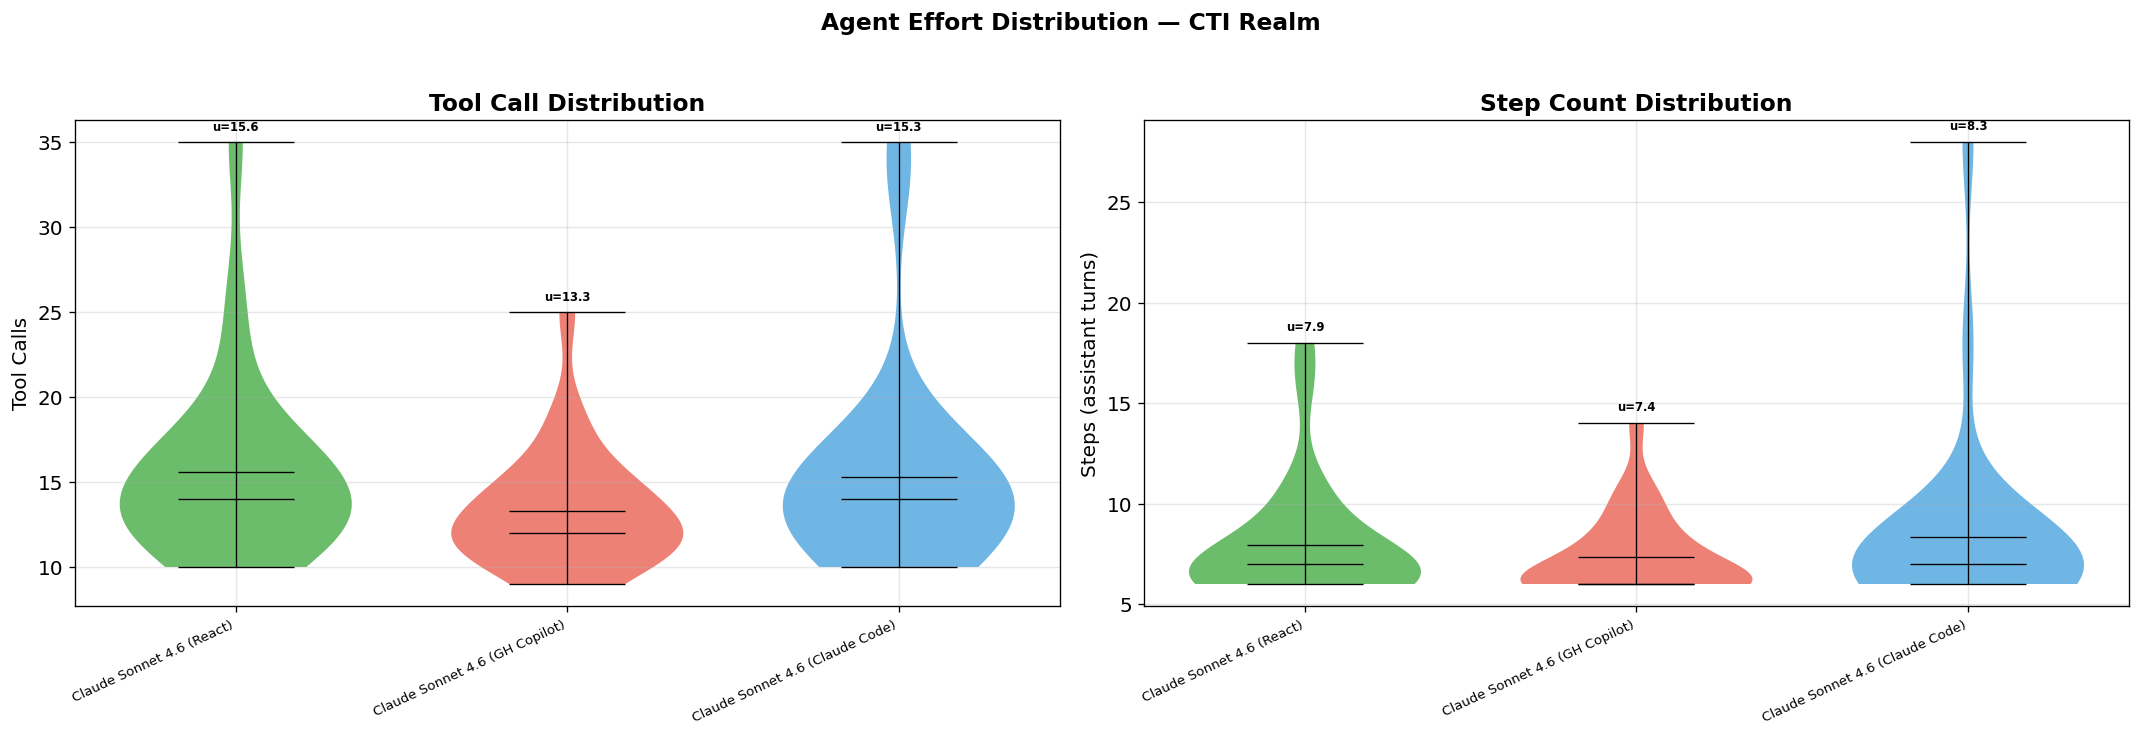

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 8b: Effort distribution (violin)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Panel 1: Tool call distribution
ax = axes[0]
for i, m in enumerate(active_traj):
    data = traj_df[traj_df['model'] == m]['n_tool_calls'].values
    vp = ax.violinplot([data], positions=[i], showmeans=True, showmedians=True, widths=0.7)
    for pc in vp['bodies']:
        pc.set_facecolor(COLORS[m])
        pc.set_alpha(0.7)
    for part in ('cmaxes', 'cmins', 'cbars', 'cmeans', 'cmedians'):
        if part in vp:
            vp[part].set_edgecolor('black')
            vp[part].set_linewidth(0.8)
    ax.text(i, data.max() + 0.5, f'u={np.mean(data):.1f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
ax.set_xticks(range(len(active_traj)))
ax.set_xticklabels(active_traj, fontsize=8, rotation=25, ha='right')
ax.set_ylabel('Tool Calls')
ax.set_title('Tool Call Distribution', fontweight='bold')

# Panel 2: Step count distribution
ax = axes[1]
for i, m in enumerate(active_traj):
    data = traj_df[traj_df['model'] == m]['n_steps'].values
    vp = ax.violinplot([data], positions=[i], showmeans=True, showmedians=True, widths=0.7)
    for pc in vp['bodies']:
        pc.set_facecolor(COLORS[m])
        pc.set_alpha(0.7)
    for part in ('cmaxes', 'cmins', 'cbars', 'cmeans', 'cmedians'):
        if part in vp:
            vp[part].set_edgecolor('black')
            vp[part].set_linewidth(0.8)
    ax.text(i, data.max() + 0.5, f'u={np.mean(data):.1f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
ax.set_xticks(range(len(active_traj)))
ax.set_xticklabels(active_traj, fontsize=8, rotation=25, ha='right')
ax.set_ylabel('Steps (assistant turns)')
ax.set_title('Step Count Distribution', fontweight='bold')

fig.suptitle(f'Agent Effort Distribution — {DOMAIN_NAME}', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'effort_distributions_by_agent.png', bbox_inches='tight')
plt.show()


---

## 9. Tool Usage Analysis

### What this measures

How each agent configuration allocates its tool calls across available tools. Different agent architectures may present tools differently, leading to distinct tool usage patterns.

### How to read the chart

- **Left panel**: Mean tool calls per tool per agent config — shows absolute tool preference
- **Right panel**: Tool call ratio (fraction of calls going to each tool) — normalizes for varying total effort

### Key question

Do agent architectures influence which tools the model uses? For example, does one architecture encourage more `python` usage while another keeps the agent in `bash`? Tool selection patterns can reveal fundamental differences in how architectures frame the investigation task.

### Key insights (CTI Realm)

> _Run the cells above and analyze the results to fill in domain-specific insights._

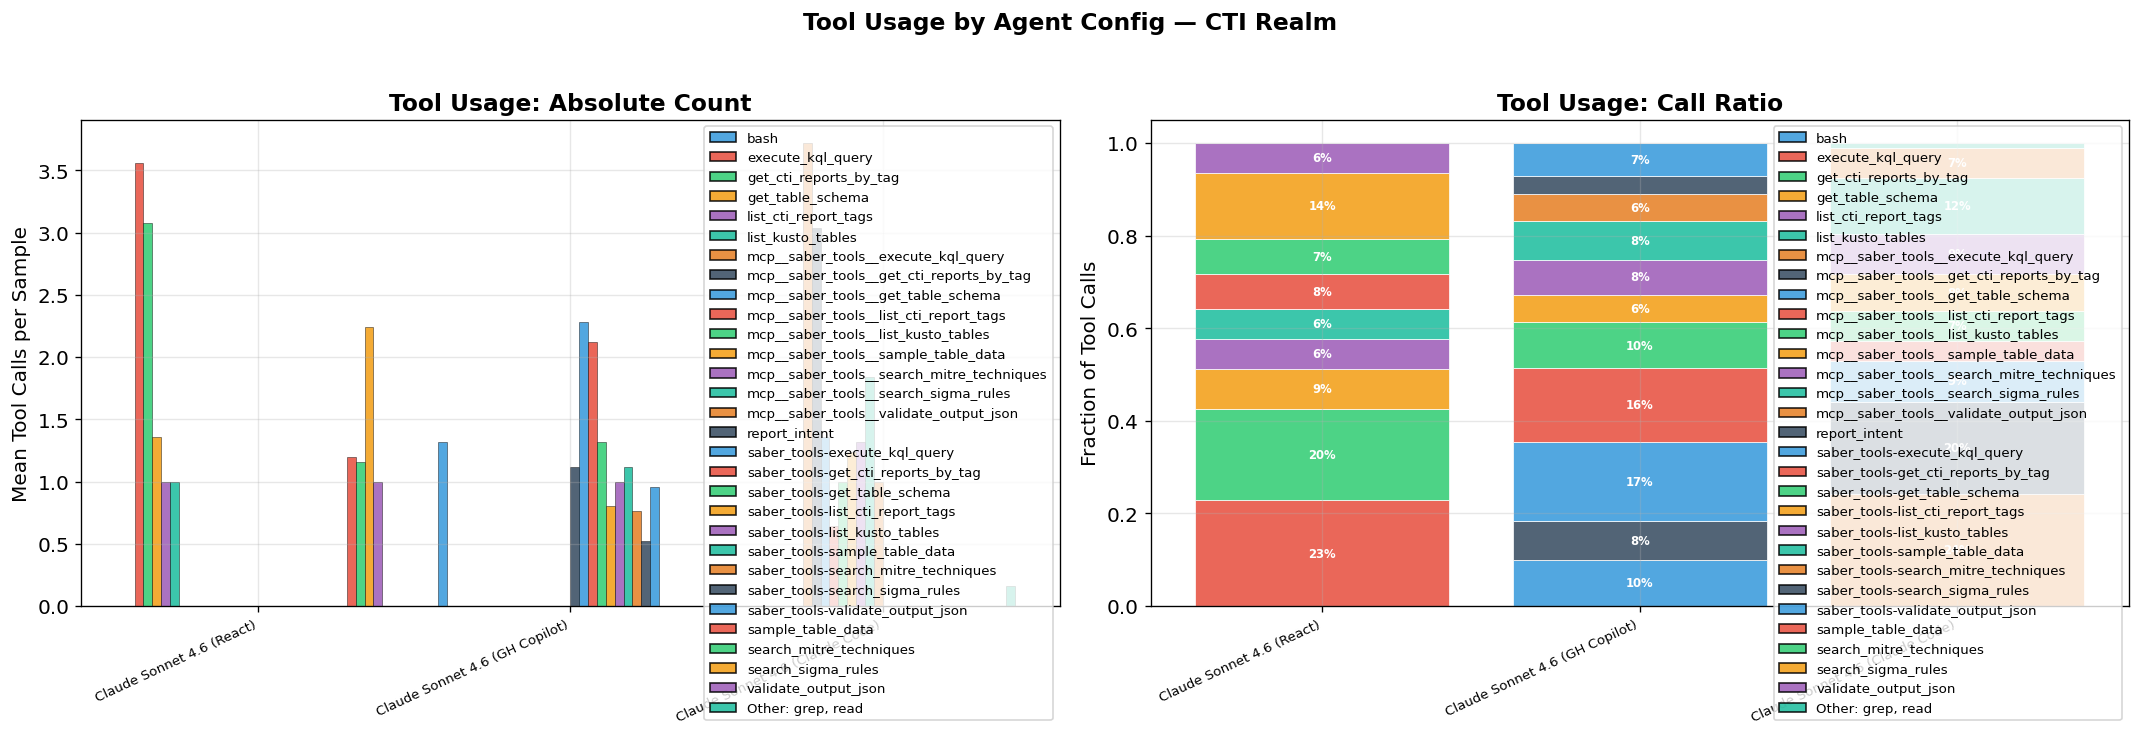


Tools aggregated into "Other (<1%)": grep, read


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 9: Tool usage breakdown per agent config
# ══════════════════════════════════════════════════════════════════════════════
tool_expanded = traj_df['tool_counts'].apply(pd.Series).fillna(0)
for col in tool_expanded.columns:
    traj_df[f'tool_{col}'] = tool_expanded[col]

tool_cols = [c for c in traj_df.columns if c.startswith('tool_') and c != 'tool_counts']
tool_names = [c.replace('tool_', '') for c in tool_cols]

# ── Aggregate minor tools (<1% of calls across all configs) into "Other" ──
total_calls_all = traj_df['n_tool_calls'].sum()
tool_totals = {tname: traj_df[col].sum() for col, tname in zip(tool_cols, tool_names)}
major_tools = [t for t, v in tool_totals.items() if v / total_calls_all >= 0.01]
minor_tools = [t for t, v in tool_totals.items() if v / total_calls_all < 0.01]

if minor_tools:
    traj_df['tool_Other (<1%)'] = sum(traj_df[f'tool_{t}'] for t in minor_tools)
    plot_tool_cols = [f'tool_{t}' for t in major_tools] + ['tool_Other (<1%)']
    minor_label = 'Other: ' + ', '.join(minor_tools)
    plot_tool_names = major_tools + [minor_label]
else:
    plot_tool_cols = tool_cols
    plot_tool_names = tool_names

tool_palette = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12', '#9B59B6', '#1ABC9C', '#E67E22', '#34495E']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Panel 1: Absolute counts
ax = axes[0]
bar_width = min(0.12, 0.85 / len(plot_tool_cols))
x = np.arange(len(active_traj))
for j, (col, tname) in enumerate(zip(plot_tool_cols, plot_tool_names)):
    offset = (j - len(plot_tool_cols)/2 + 0.5) * bar_width
    means = [traj_df[traj_df['model'] == m][col].mean() for m in active_traj]
    color = tool_palette[j % len(tool_palette)]
    ax.bar(x + offset, means, bar_width, color=color, edgecolor='black', linewidth=0.3, alpha=0.85)
tool_handles = [mpatches.Patch(facecolor=tool_palette[j % len(tool_palette)], edgecolor='black',
                                alpha=0.85, label=tname) for j, tname in enumerate(plot_tool_names)]
ax.legend(handles=tool_handles, fontsize=8, loc='upper right')
ax.set_xticks(x)
ax.set_xticklabels(active_traj, fontsize=8, rotation=25, ha='right')
ax.set_ylabel('Mean Tool Calls per Sample')
ax.set_title('Tool Usage: Absolute Count', fontweight='bold')

# Panel 2: Ratios (stacked)
ax = axes[1]
bottoms = np.zeros(len(active_traj))
for j, (col, tname) in enumerate(zip(plot_tool_cols, plot_tool_names)):
    ratios = []
    for m in active_traj:
        mdf = traj_df[traj_df['model'] == m]
        total = mdf['n_tool_calls'].sum()
        ratios.append(mdf[col].sum() / total if total > 0 else 0)
    color = tool_palette[j % len(tool_palette)]
    ax.bar(x, ratios, color=color, edgecolor='white', linewidth=0.5, bottom=bottoms, alpha=0.85)
    for i, r in enumerate(ratios):
        if r > 0.05:
            ax.text(x[i], bottoms[i] + r/2, f'{r:.0%}', ha='center', va='center', fontsize=7, fontweight='bold', color='white')
    bottoms += ratios
ax.legend(handles=tool_handles, fontsize=8, loc='upper right')
ax.set_xticks(x)
ax.set_xticklabels(active_traj, fontsize=8, rotation=25, ha='right')
ax.set_ylabel('Fraction of Tool Calls')
ax.set_title('Tool Usage: Call Ratio', fontweight='bold')
ax.set_ylim(0, 1.05)

fig.suptitle(f'Tool Usage by Agent Config — {DOMAIN_NAME}', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'tool_usage_by_agent.png', bbox_inches='tight')
plt.show()

if minor_tools:
    print(f'\nTools aggregated into "Other (<1%)": {", ".join(minor_tools)}')

---

## 10. Time Efficiency & Reward Per Tool Call

### What this measures

Three dimensions of agent efficiency per architecture:

1. **Reward per tool call** — how much score does each config earn per unit of effort?
   $\text{Reward/Call} = \frac{\text{Mean SABER Score}}{\text{Mean Tool Calls}}$

2. **Reward per minute** — score per wall-clock minute of inference time

3. **Time per sample distribution** — how long does each agent config take to complete a task?

### How to read the charts

- **Reward/Call**: Higher = more efficient use of tool-call budget
- **Reward/Minute**: Higher = faster and more accurate
- **Time distribution**: Tight and low = predictable fast execution; long tails = some tasks take disproportionately long

### Key question

Which agent architecture extracts the most value from each tool call and each minute of inference time? An architecture with high reward/call is "efficient" — it doesn't waste tool invocations. An architecture with high reward/minute is ideal for time-constrained deployments.

### Key insights (CTI Realm)

> _Run the cells above and analyze the results to fill in domain-specific insights._

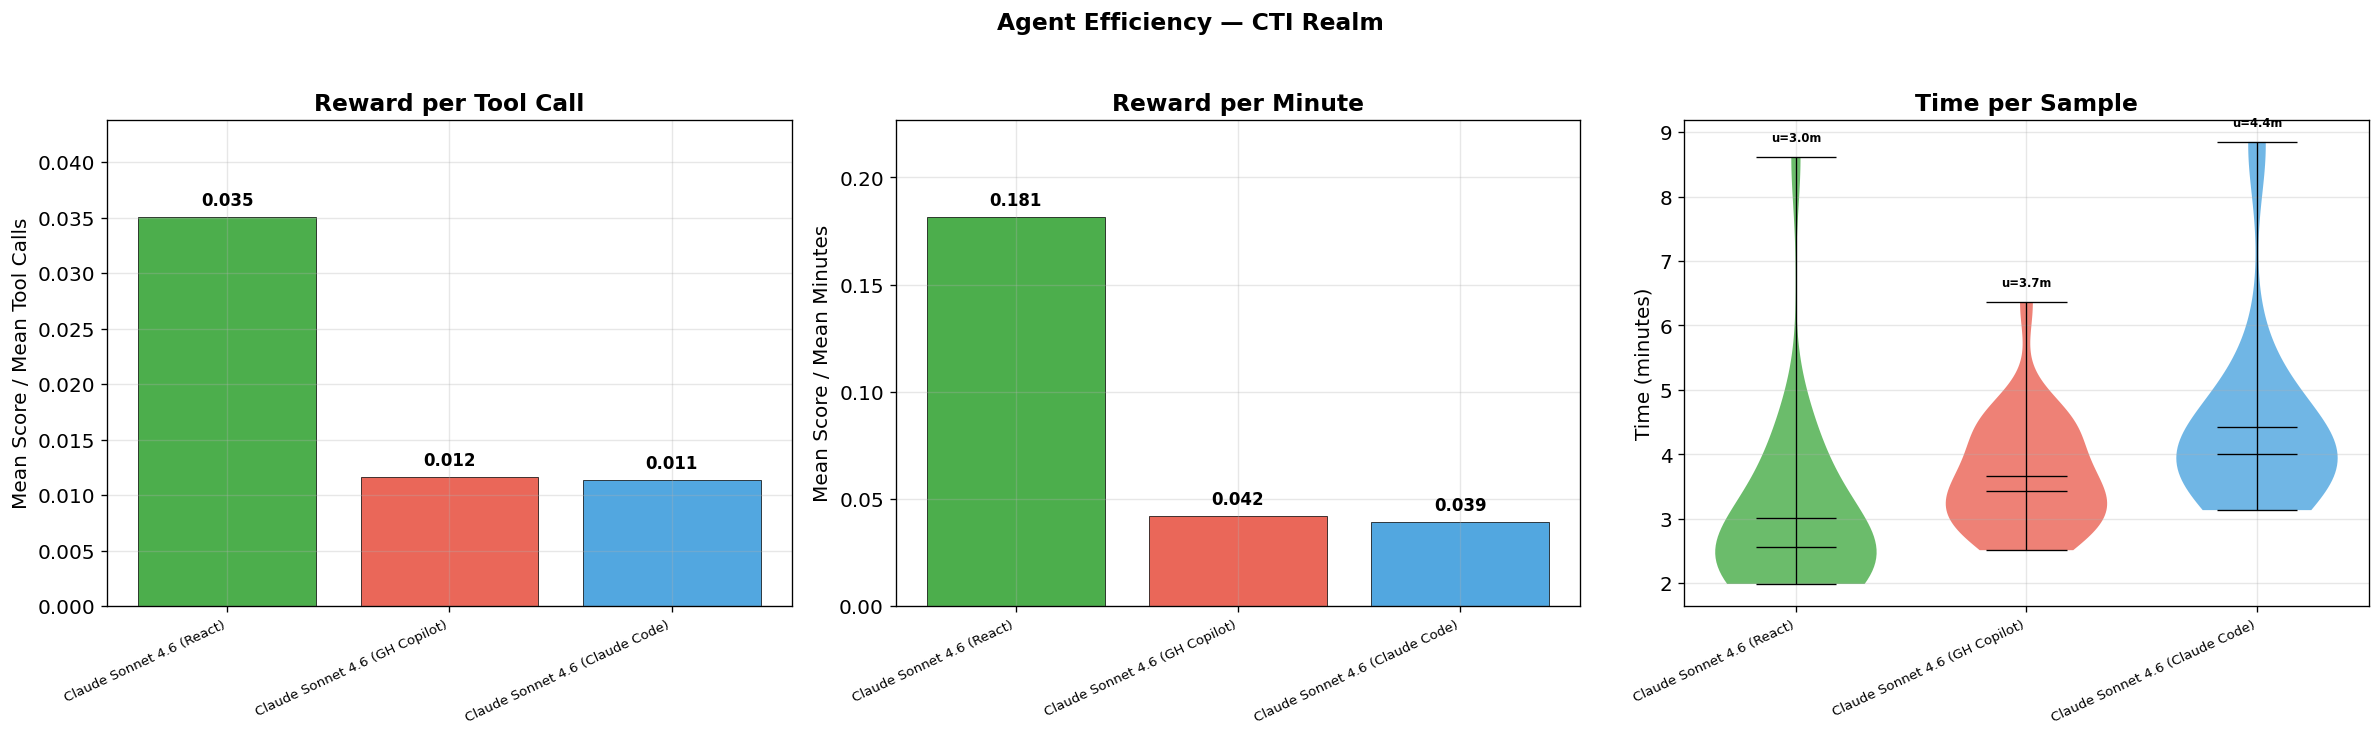

Efficiency Summary
Config                               Score   Calls    Time   Rew/Call    Rew/Min
--------------------------------------------------------------------------------
Claude Sonnet 4.6 (React)            0.547    15.6    3.0m     0.0350     0.1815
Claude Sonnet 4.6 (GH Copilot)       0.154    13.3    3.7m     0.0116     0.0422
Claude Sonnet 4.6 (Claude Code)      0.174    15.3    4.4m     0.0113     0.0393


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 10: Time efficiency and reward per tool call
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: Reward per tool call
ax = axes[0]
reward_per_call = []
for m in active_traj:
    mdf = traj_df[traj_df['model'] == m]
    rpc = mdf['score'].mean() / mdf['n_tool_calls'].mean()
    reward_per_call.append(rpc)
for i, (m, rpc) in enumerate(zip(active_traj, reward_per_call)):
    ax.bar(i, rpc, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, rpc + max(reward_per_call)*0.02, f'{rpc:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_xticks(range(len(active_traj)))
ax.set_xticklabels(active_traj, fontsize=8, rotation=25, ha='right')
ax.set_ylabel('Mean Score / Mean Tool Calls')
ax.set_title('Reward per Tool Call', fontweight='bold')
ax.set_ylim(0, max(reward_per_call) * 1.25)

# Panel 2: Reward per minute
ax = axes[1]
reward_per_min = []
for m in active_traj:
    mdf = traj_df[traj_df['model'] == m]
    rpm = mdf['score'].mean() / (mdf['total_time'].mean() / 60)
    reward_per_min.append(rpm)
for i, (m, rpm) in enumerate(zip(active_traj, reward_per_min)):
    ax.bar(i, rpm, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, rpm + max(reward_per_min)*0.02, f'{rpm:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_xticks(range(len(active_traj)))
ax.set_xticklabels(active_traj, fontsize=8, rotation=25, ha='right')
ax.set_ylabel('Mean Score / Mean Minutes')
ax.set_title('Reward per Minute', fontweight='bold')
ax.set_ylim(0, max(reward_per_min) * 1.25)

# Panel 3: Time distribution
ax = axes[2]
for i, m in enumerate(active_traj):
    data = traj_df[traj_df['model'] == m]['total_time'].values / 60
    vp = ax.violinplot([data], positions=[i], showmeans=True, showmedians=True, widths=0.7)
    for pc in vp['bodies']:
        pc.set_facecolor(COLORS[m])
        pc.set_alpha(0.7)
    for part in ('cmaxes', 'cmins', 'cbars', 'cmeans', 'cmedians'):
        if part in vp:
            vp[part].set_edgecolor('black')
            vp[part].set_linewidth(0.8)
    ax.text(i, data.max() + 0.2, f'u={np.mean(data):.1f}m', ha='center', va='bottom', fontsize=7, fontweight='bold')
ax.set_xticks(range(len(active_traj)))
ax.set_xticklabels(active_traj, fontsize=8, rotation=25, ha='right')
ax.set_ylabel('Time (minutes)')
ax.set_title('Time per Sample', fontweight='bold')

fig.suptitle(f'Agent Efficiency — {DOMAIN_NAME}', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'agent_efficiency_by_agent.png', bbox_inches='tight')
plt.show()

print('Efficiency Summary')
print(f'{"Config":35s} {"Score":>6s} {"Calls":>7s} {"Time":>7s} {"Rew/Call":>10s} {"Rew/Min":>10s}')
print('-' * 80)
for m, rpc, rpm in zip(active_traj, reward_per_call, reward_per_min):
    mdf = traj_df[traj_df['model'] == m]
    print(f'{m:35s} {mdf["score"].mean():6.3f} {mdf["n_tool_calls"].mean():7.1f} '
          f'{mdf["total_time"].mean()/60:6.1f}m {rpc:10.4f} {rpm:10.4f}')


---

## 11. Score Outcome Segmentation by Effort

### What this measures

Segments samples into **effort quartiles** by tool-call count and shows what fraction of tasks in each quartile achieve a **perfect score** (1.0) vs. **zero** (0.0) vs. **partial** (0 < score < 1).

### How to read the chart

- One panel per agent config; bars show Q1 (lowest effort) through Q4 (highest effort)
- **Green** = perfect score, **Orange** = partial, **Red** = zero
- Q1 is typically dominated by "easy" tasks solved in few calls
- Q4 contains the hardest tasks where the agent exhausted more of its budget

### Key question

Do agent architectures degrade differently under high effort? An architecture where Q4 still has a high perfect-score rate handles hard tasks gracefully. An architecture where Q4 collapses to mostly zeros indicates the hard tasks are genuinely unsolvable under that agent design, or that the architecture wastes tool calls on unproductive actions.

### Key insights (CTI Realm)

> _Run the cells above and analyze the results to fill in domain-specific insights._

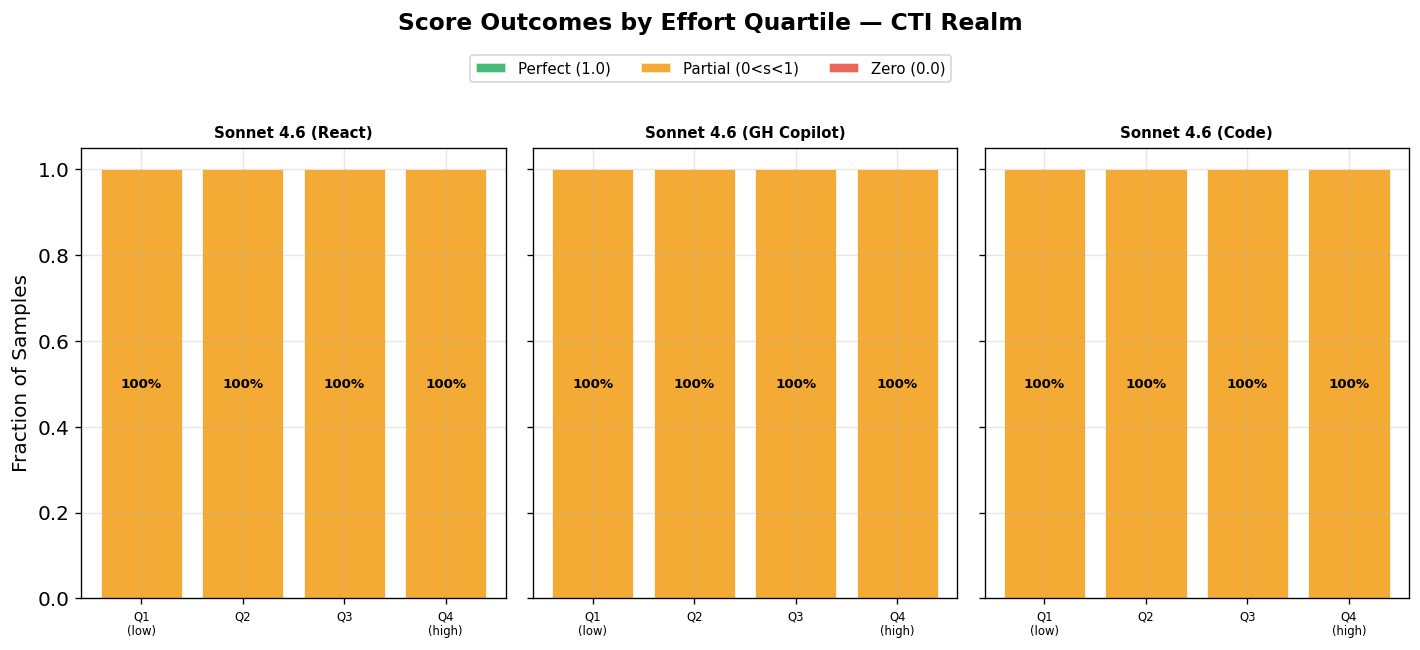

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 11: Score outcome segmentation by effort quartile
# ══════════════════════════════════════════════════════════════════════════════
outcome_colors = {'Perfect (1.0)': '#27AE60', 'Partial (0<s<1)': '#F39C12', 'Zero (0.0)': '#E74C3C'}
n_configs = len(active_traj)
fig, axes = plt.subplots(1, min(n_configs, 8), figsize=(4 * min(n_configs, 8), 5), sharey=True)
if n_configs == 1:
    axes = [axes]

for ax, m in zip(axes, active_traj[:8]):
    mdf = traj_df[traj_df['model'] == m].copy()
    try:
        mdf['effort_q'] = pd.qcut(mdf['n_tool_calls'], q=4, labels=['Q1\n(low)', 'Q2', 'Q3', 'Q4\n(high)'], duplicates='drop')
    except ValueError:
        continue

    mdf['outcome'] = 'Partial (0<s<1)'
    mdf.loc[mdf['score'] >= 1.0 - 1e-6, 'outcome'] = 'Perfect (1.0)'
    mdf.loc[mdf['score'] <= 1e-6, 'outcome'] = 'Zero (0.0)'

    ct = pd.crosstab(mdf['effort_q'], mdf['outcome'], normalize='index')
    ct = ct.reindex(columns=['Perfect (1.0)', 'Partial (0<s<1)', 'Zero (0.0)'], fill_value=0)

    bottoms = np.zeros(len(ct))
    for outcome_cat in ['Perfect (1.0)', 'Partial (0<s<1)', 'Zero (0.0)']:
        if outcome_cat not in ct.columns:
            continue
        vals = ct[outcome_cat].values
        ax.bar(range(len(ct)), vals, bottom=bottoms, color=outcome_colors[outcome_cat],
               edgecolor='white', linewidth=0.5, alpha=0.85)
        for xi, (v, b) in enumerate(zip(vals, bottoms)):
            if v > 0.05:
                ax.text(xi, b + v/2, f'{v:.0%}', ha='center', va='center', fontsize=8, fontweight='bold')
        bottoms += vals

    short = m.replace('Claude ', '').replace('GPT-', 'GPT')
    ax.set_title(short, fontweight='bold', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_xticks(range(len(ct)))
    ax.set_xticklabels(ct.index, fontsize=7)

axes[0].set_ylabel('Fraction of Samples')
handles = [mpatches.Patch(facecolor=c, edgecolor='white', alpha=0.85, label=k) for k, c in outcome_colors.items()]
fig.legend(handles=handles, loc='upper center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, 1.02))
fig.suptitle(f'Score Outcomes by Effort Quartile — {DOMAIN_NAME}', fontweight='bold', fontsize=14, y=1.08)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'effort_outcome_by_agent.png', bbox_inches='tight')
plt.show()


---

## 12. Cross-Config Difficulty Agreement

### What this measures

Do different agent configurations agree on which tasks are hard? For each pair of configs, computes the **Spearman rank correlation** of their per-sample scores.

### How to read the chart

- **High correlation (> 0.7)** = configs agree on task difficulty — the architecture doesn't change which tasks are hard
- **Low correlation (< 0.3)** = configs struggle on different tasks — architectures have complementary strengths
- * = statistically significant (p < 0.05)

### Key question

Is task difficulty an intrinsic property of the task (high correlation across all configs), or is it mediated by agent architecture (low correlation)? High same-model cross-architecture correlation means the architecture doesn't change the difficulty landscape. Low correlation means the architecture meaningfully changes which tasks succeed — suggesting potential for **architecture-level ensembles**.

### Key insights (CTI Realm)

> _Run the cells above and analyze the results to fill in domain-specific insights._

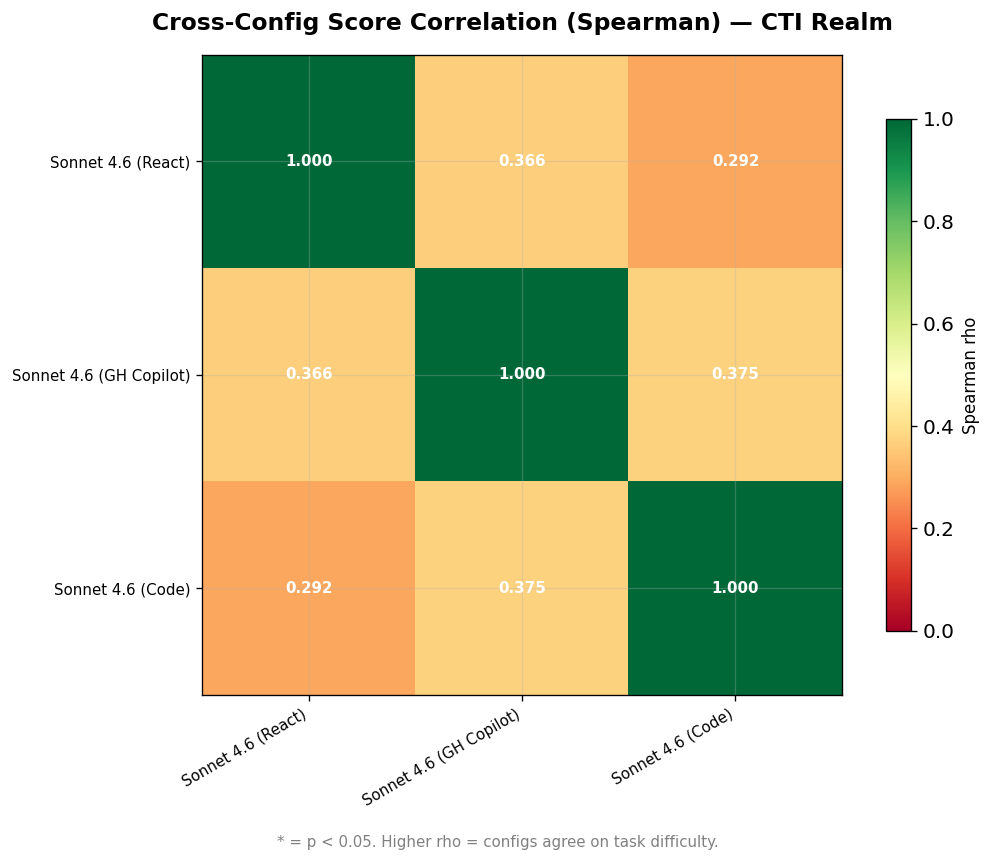

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 12: Cross-config difficulty agreement (Spearman correlation)
# ══════════════════════════════════════════════════════════════════════════════
from scipy.stats import spearmanr

active_configs = [m for m in MODEL_ORDER if m in model_overall]
score_pivot = samples_df.pivot(index='sample_id', columns='model', values='score').reindex(columns=active_configs)

n = len(active_configs)
corr_matrix = np.ones((n, n))
p_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(i+1, n):
        m1, m2 = active_configs[i], active_configs[j]
        valid = score_pivot[[m1, m2]].dropna()
        if len(valid) > 2:
            rho, p = spearmanr(valid[m1], valid[m2])
            corr_matrix[i, j] = corr_matrix[j, i] = rho
            p_matrix[i, j] = p_matrix[j, i] = p

fig, ax = plt.subplots(figsize=(max(9, n * 1.2), max(7, n * 1.0)))
im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='equal')

for i in range(n):
    for j in range(n):
        val = corr_matrix[i, j]
        text_color = 'white' if val < 0.4 or val > 0.85 else 'black'
        sig = '' if i == j else ('*' if p_matrix[i, j] < 0.05 else '')
        ax.text(j, i, f'{val:.3f}{sig}', ha='center', va='center',
                fontsize=9, fontweight='bold', color=text_color)

short_labels = [m.replace('Claude ', '').replace('GPT-', 'GPT') for m in active_configs]
ax.set_xticks(range(n)); ax.set_xticklabels(short_labels, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(n)); ax.set_yticklabels(short_labels, fontsize=9)
ax.set_title(f'Cross-Config Score Correlation (Spearman) — {DOMAIN_NAME}', fontweight='bold', pad=15)
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Spearman rho', fontsize=10)
fig.text(0.5, -0.02, '* = p < 0.05. Higher rho = configs agree on task difficulty.',
         ha='center', fontsize=9, fontstyle='italic', color='gray')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'cross_config_correlation.png', bbox_inches='tight')
plt.show()


---

# Domain-Specific Experiments (CTI Realm)

The following experiments are specific to the **CTI Realm** domain and analyze patterns unique to cyber threat intelligence tasks, including checkpoint heatmaps, CTI/MITRE tool usage, KQL query quality, and checkpoint correlations.

---

## 1. Checkpoint Score Heatmap by Agent Architecture

### What this measures

A heatmap showing **mean checkpoint scores per platform per agent configuration**. Each checkpoint (C0–C4) captures a distinct CTI skill, and different agent architectures may strengthen or weaken specific capabilities.

### How to read the chart

- **Left panel**: Raw checkpoint scores per agent config across platforms — brighter green = higher score
- **Right panel**: Agent architecture difference from React baseline — green = agent outperforms React, red = underperforms
- Rows = agent configurations; columns = platform x checkpoint combinations

### Key questions

- Does agent architecture affect which checkpoints succeed? (e.g., does Copilot improve C4 detection writing but hurt C0 CTI alignment?)
- Are platform-specific advantages consistent across architectures?
- Which checkpoint shows the largest architecture sensitivity?

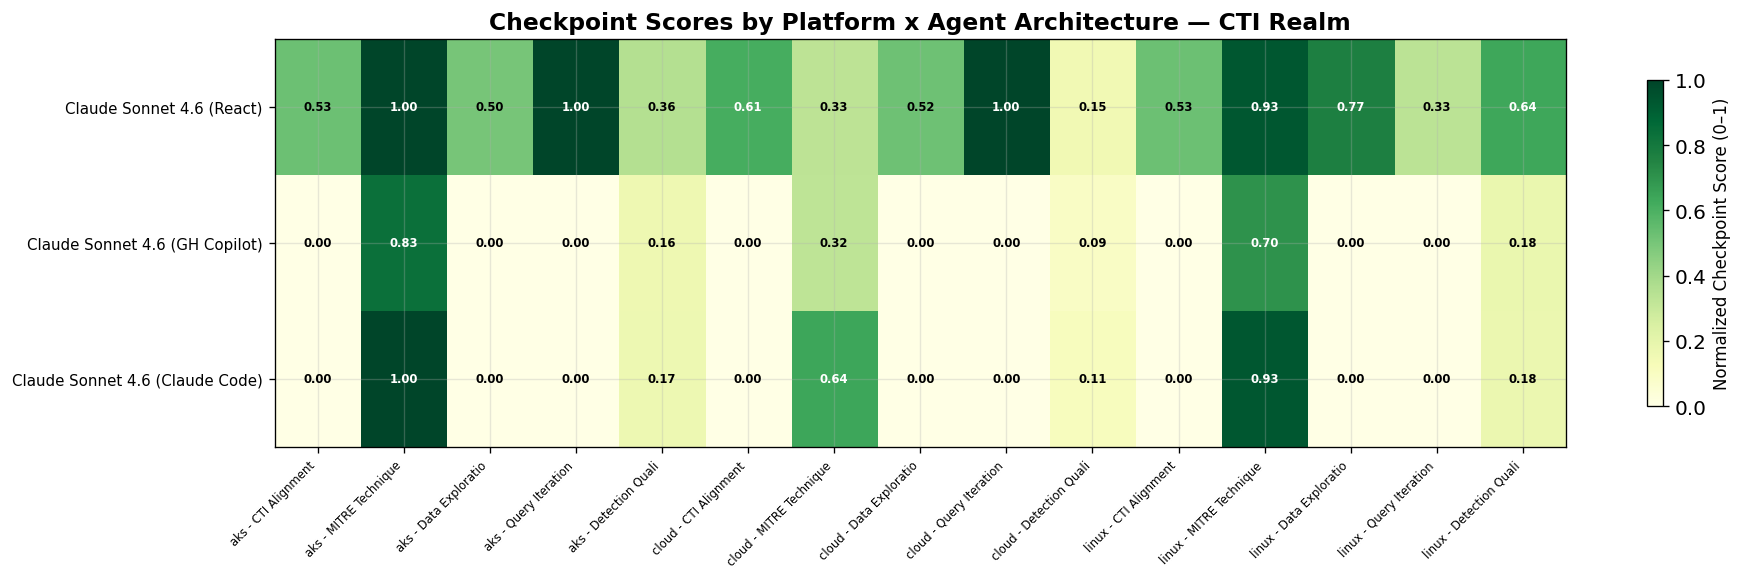


Checkpoint Architecture Sensitivity (std across configs):
  C0: CTI Alignment               min=0.000  max=0.555  spread=0.555  (Claude Sonnet 4.6 (GH Copilot) → Claude Sonnet 4.6 (React))
  C1: MITRE Techniques            min=0.619  max=0.858  spread=0.238  (Claude Sonnet 4.6 (GH Copilot) → Claude Sonnet 4.6 (Claude Code))
  C2: Data Exploration            min=0.000  max=0.596  spread=0.596  (Claude Sonnet 4.6 (GH Copilot) → Claude Sonnet 4.6 (React))
  C3: Query Iteration             min=0.000  max=0.778  spread=0.778  (Claude Sonnet 4.6 (GH Copilot) → Claude Sonnet 4.6 (React))
  C4: Detection Quality           min=0.144  max=0.380  spread=0.236  (Claude Sonnet 4.6 (GH Copilot) → Claude Sonnet 4.6 (React))


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 1: Checkpoint Score Heatmap by Agent Architecture
# ══════════════════════════════════════════════════════════════════════════════
checkpoints = list(CHECKPOINT_NAMES.keys())
active_configs = [m for m in MODEL_ORDER if m in model_overall]

# Build checkpoint × platform × config matrix
ckpt_platform = []
for m in active_configs:
    m_sub = subtasks_df[subtasks_df['model'] == m]
    m_samp = samples_df[samples_df['model'] == m]
    for platform in sorted(samples_df['group'].unique()):
        platform_sids = m_samp[m_samp['group'] == platform]['sample_id'].unique()
        for ck in checkpoints:
            ck_scores = m_sub[(m_sub['score_type'] == ck) & (m_sub['sample_id'].isin(platform_sids))]['score']
            if len(ck_scores) > 0:
                # Normalize by max score
                max_score = CHECKPOINT_MAX_SCORES.get(ck, 1.0)
                ckpt_platform.append({
                    'model': m, 'platform': platform, 'checkpoint': ck,
                    'score': ck_scores.mean(), 'normalized': ck_scores.mean() / max_score,
                })

ckpt_df = pd.DataFrame(ckpt_platform)

# Create combined column label: "Platform - Checkpoint"
ckpt_df['col_label'] = ckpt_df['platform'] + ' - ' + ckpt_df['checkpoint'].map(
    lambda ck: CHECKPOINT_NAMES[ck].split(': ')[1][:15])

# Pivot for heatmap
heat_pivot = ckpt_df.pivot_table(index='model', columns='col_label', values='normalized', aggfunc='mean')
heat_pivot = heat_pivot.reindex(active_configs)

# Sort columns by platform then checkpoint
col_order = []
for platform in sorted(samples_df['group'].unique()):
    for ck in checkpoints:
        short = CHECKPOINT_NAMES[ck].split(': ')[1][:15]
        label = f'{platform} - {short}'
        if label in heat_pivot.columns:
            col_order.append(label)
heat_pivot = heat_pivot[col_order]

fig, ax = plt.subplots(figsize=(max(16, len(col_order) * 0.9), max(5, len(active_configs) * 1.2)))
im = ax.imshow(heat_pivot.values, cmap='YlGn', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(col_order)))
ax.set_xticklabels(col_order, fontsize=7, rotation=45, ha='right')
ax.set_yticks(range(len(active_configs)))
ax.set_yticklabels(active_configs, fontsize=9)

for i, m in enumerate(active_configs):
    for j, col in enumerate(col_order):
        val = heat_pivot.loc[m, col]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7,
                    fontweight='bold', color='white' if val > 0.6 else 'black')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Normalized Checkpoint Score (0–1)', fontsize=10)
ax.set_title(f'Checkpoint Scores by Platform x Agent Architecture — {DOMAIN_NAME}', fontweight='bold')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'checkpoint_heatmap_by_agent.png', bbox_inches='tight')
plt.show()

# Summary: which checkpoints are most architecture-sensitive?
print('\nCheckpoint Architecture Sensitivity (std across configs):')
for ck in checkpoints:
    ck_short = CHECKPOINT_NAMES[ck]
    ck_cols = [c for c in col_order if ck_short.split(': ')[1][:15] in c]
    if ck_cols:
        vals = heat_pivot[ck_cols].mean(axis=1)
        print(f'  {ck_short:30s}  '
              f'min={vals.min():.3f}  max={vals.max():.3f}  '
              f'spread={vals.max()-vals.min():.3f}  '
              f'({active_configs[vals.argmin()]} → {active_configs[vals.argmax()]})')

---

## 2. CTI & MITRE Tool Usage by Agent Architecture

### What this measures

Examines how each agent architecture leverages the **9 CTI-specific tools**:

- **(a) Mean Tool Calls per Sample** — grouped bar chart of all CTI tools per agent config
- **(b) Investigation Workflow Funnel** — traces the expected flow: CTI reports → MITRE mapping → KQL querying → validation
- **(c) KQL Query Count Distribution** — violin plot per agent config
- **(d) KQL Queries vs. C4 Detection Quality** — scatter testing whether more queries → better detection

### Key questions

- Do agent architectures produce different investigation strategies?
- Does one architecture encourage more systematic use of CTI reports before querying?
- Which architecture produces the most efficient KQL querying (fewer queries for same C4 score)?

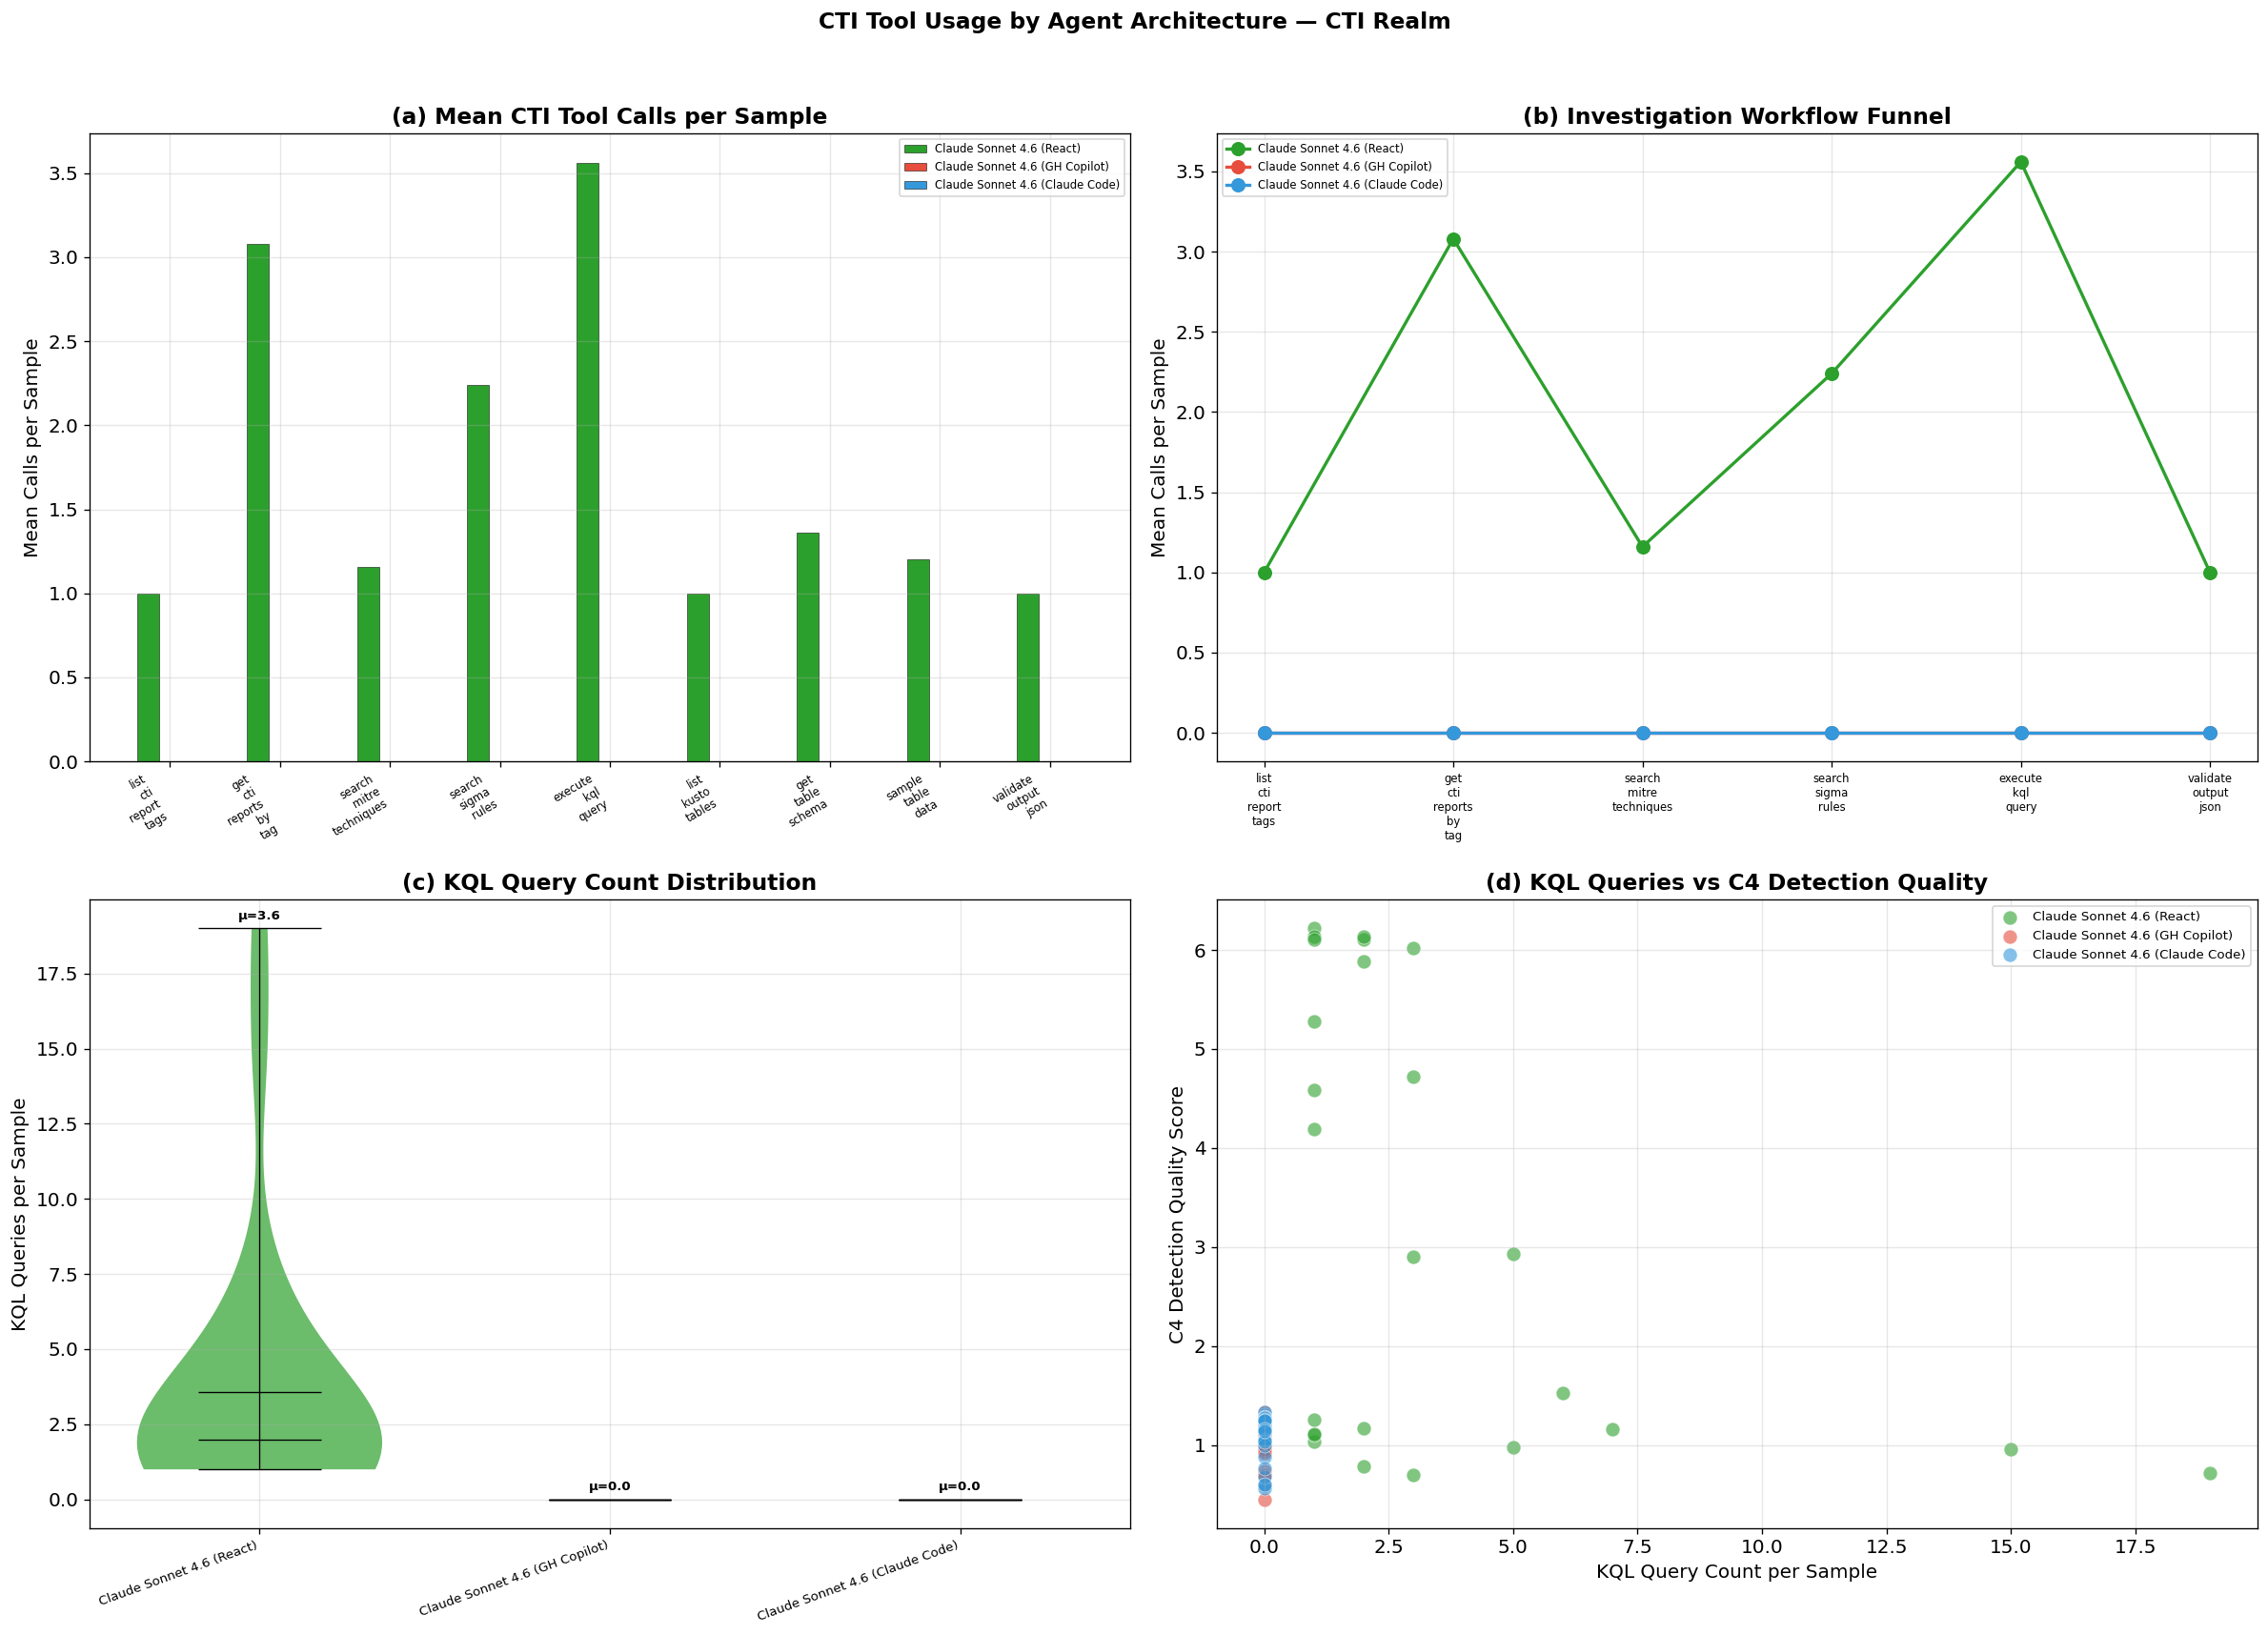


CTI Tool Usage Summary per Agent Config
Config                                KQL  CTI Rpt   MITRE   Sigma  Validate
---------------------------------------------------------------------------
Claude Sonnet 4.6 (React)             3.6      3.1     1.2     2.2       1.0
Claude Sonnet 4.6 (GH Copilot)        0.0      0.0     0.0     0.0       0.0
Claude Sonnet 4.6 (Claude Code)       0.0      0.0     0.0     0.0       0.0


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 2: CTI & MITRE Tool Usage by Agent Architecture
# ══════════════════════════════════════════════════════════════════════════════
# Build per-sample tool counts for CTI tools
cti_records = []
for m in MODEL_ORDER:
    mdf = traj_df[traj_df['model'] == m]
    for _, row in mdf.iterrows():
        rec = {'model': m, 'sample_id': row['sample_id']}
        for t in CTI_TOOLS:
            col = f'tool_{t}'
            rec[t] = int(row[col]) if col in row.index else 0
        cti_records.append(rec)

cti_df = pd.DataFrame(cti_records)

# Get C4 scores for scatter plot
c4_lookup = subtasks_df[subtasks_df['score_type'] == 'c4_detection_quality'][['model', 'sample_id', 'score']].copy()
c4_lookup = c4_lookup.rename(columns={'score': 'c4_score'})

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# (a) Mean calls per tool per agent config — grouped bar
ax = axes[0, 0]
x = np.arange(len(CTI_TOOLS))
n_configs = len(active_traj)
width = min(0.2, 0.85 / n_configs)
for i, m in enumerate(active_traj):
    mdf = cti_df[cti_df['model'] == m]
    means = [mdf[t].mean() for t in CTI_TOOLS]
    ax.bar(x + i * width, means, width, label=m, color=COLORS[m], edgecolor='black', linewidth=0.3)
ax.set_xticks(x + width * (n_configs - 1) / 2)
ax.set_xticklabels([t.replace('_', '\n') for t in CTI_TOOLS], fontsize=7, rotation=30, ha='right')
ax.set_ylabel('Mean Calls per Sample')
ax.set_title('(a) Mean CTI Tool Calls per Sample', fontweight='bold')
ax.legend(fontsize=7)

# (b) Investigation workflow funnel
ax = axes[0, 1]
funnel_tools = ['list_cti_report_tags', 'get_cti_reports_by_tag', 'search_mitre_techniques',
                'search_sigma_rules', 'execute_kql_query', 'validate_output_json']
for m in active_traj:
    mdf = cti_df[cti_df['model'] == m]
    means = [mdf[t].mean() for t in funnel_tools]
    ax.plot(range(len(funnel_tools)), means, 'o-', label=m, color=COLORS[m], linewidth=2, markersize=8)
ax.set_xticks(range(len(funnel_tools)))
ax.set_xticklabels([t.replace('_', '\n') for t in funnel_tools], fontsize=7)
ax.set_ylabel('Mean Calls per Sample')
ax.set_title('(b) Investigation Workflow Funnel', fontweight='bold')
ax.legend(fontsize=7)

# (c) KQL query count distribution
ax = axes[1, 0]
for i, m in enumerate(active_traj):
    data = cti_df[cti_df['model'] == m]['execute_kql_query'].values
    if len(data) > 0:
        vp = ax.violinplot([data], positions=[i], showmeans=True, showmedians=True, widths=0.7)
        for pc in vp['bodies']:
            pc.set_facecolor(COLORS[m]); pc.set_alpha(0.7)
        for part in ('cmaxes', 'cmins', 'cbars', 'cmeans', 'cmedians'):
            if part in vp:
                vp[part].set_edgecolor('black'); vp[part].set_linewidth(0.8)
        ax.text(i, data.max() + 0.3, f'μ={np.mean(data):.1f}', ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(range(len(active_traj)))
ax.set_xticklabels(active_traj, fontsize=8, rotation=20, ha='right')
ax.set_ylabel('KQL Queries per Sample')
ax.set_title('(c) KQL Query Count Distribution', fontweight='bold')

# (d) KQL count vs C4 score
ax = axes[1, 1]
cti_c4 = cti_df.merge(c4_lookup, on=['model', 'sample_id'], how='left')
for m in active_traj:
    mdf = cti_c4[cti_c4['model'] == m]
    ax.scatter(mdf['execute_kql_query'], mdf['c4_score'], label=m,
               color=COLORS[m], alpha=0.6, s=80, edgecolors='w', linewidths=0.5)
ax.set_xlabel('KQL Query Count per Sample')
ax.set_ylabel('C4 Detection Quality Score')
ax.set_title('(d) KQL Queries vs C4 Detection Quality', fontweight='bold')
ax.legend(fontsize=8)

fig.suptitle(f'CTI Tool Usage by Agent Architecture — {DOMAIN_NAME}', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'cti_tool_usage_by_agent.png', bbox_inches='tight')
plt.show()

# Summary table
print('\nCTI Tool Usage Summary per Agent Config')
print(f'{"Config":35s} {"KQL":>5s} {"CTI Rpt":>8s} {"MITRE":>7s} {"Sigma":>7s} {"Validate":>9s}')
print('-' * 75)
for m in active_traj:
    mdf = cti_df[cti_df['model'] == m]
    print(f'{m:35s} {mdf["execute_kql_query"].mean():5.1f} '
          f'{mdf["get_cti_reports_by_tag"].mean():8.1f} '
          f'{mdf["search_mitre_techniques"].mean():7.1f} '
          f'{mdf["search_sigma_rules"].mean():7.1f} '
          f'{mdf["validate_output_json"].mean():9.1f}')

---

## 3. KQL Query Quality Analysis by Agent Architecture

### What this measures

Deeper analysis of KQL querying behavior per agent configuration:

- **(a) Total KQL Queries** — absolute volume per agent config
- **(b) Per-Sample Distribution** — box plot showing query count variance
- **(c) KQL Efficiency** — C4 score per KQL query (higher = more efficient querying)

### Key questions

- Which architecture writes the most KQL queries? Is more always better?
- Which architecture is the most KQL-efficient (highest C4 score per query)?
- Do architectures with fewer but more targeted queries outperform those that brute-force?

/tmp/ipykernel_66174/2984263663.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=[m.replace('Claude ', '').replace('GPT-', 'GPT') for m in active_traj],


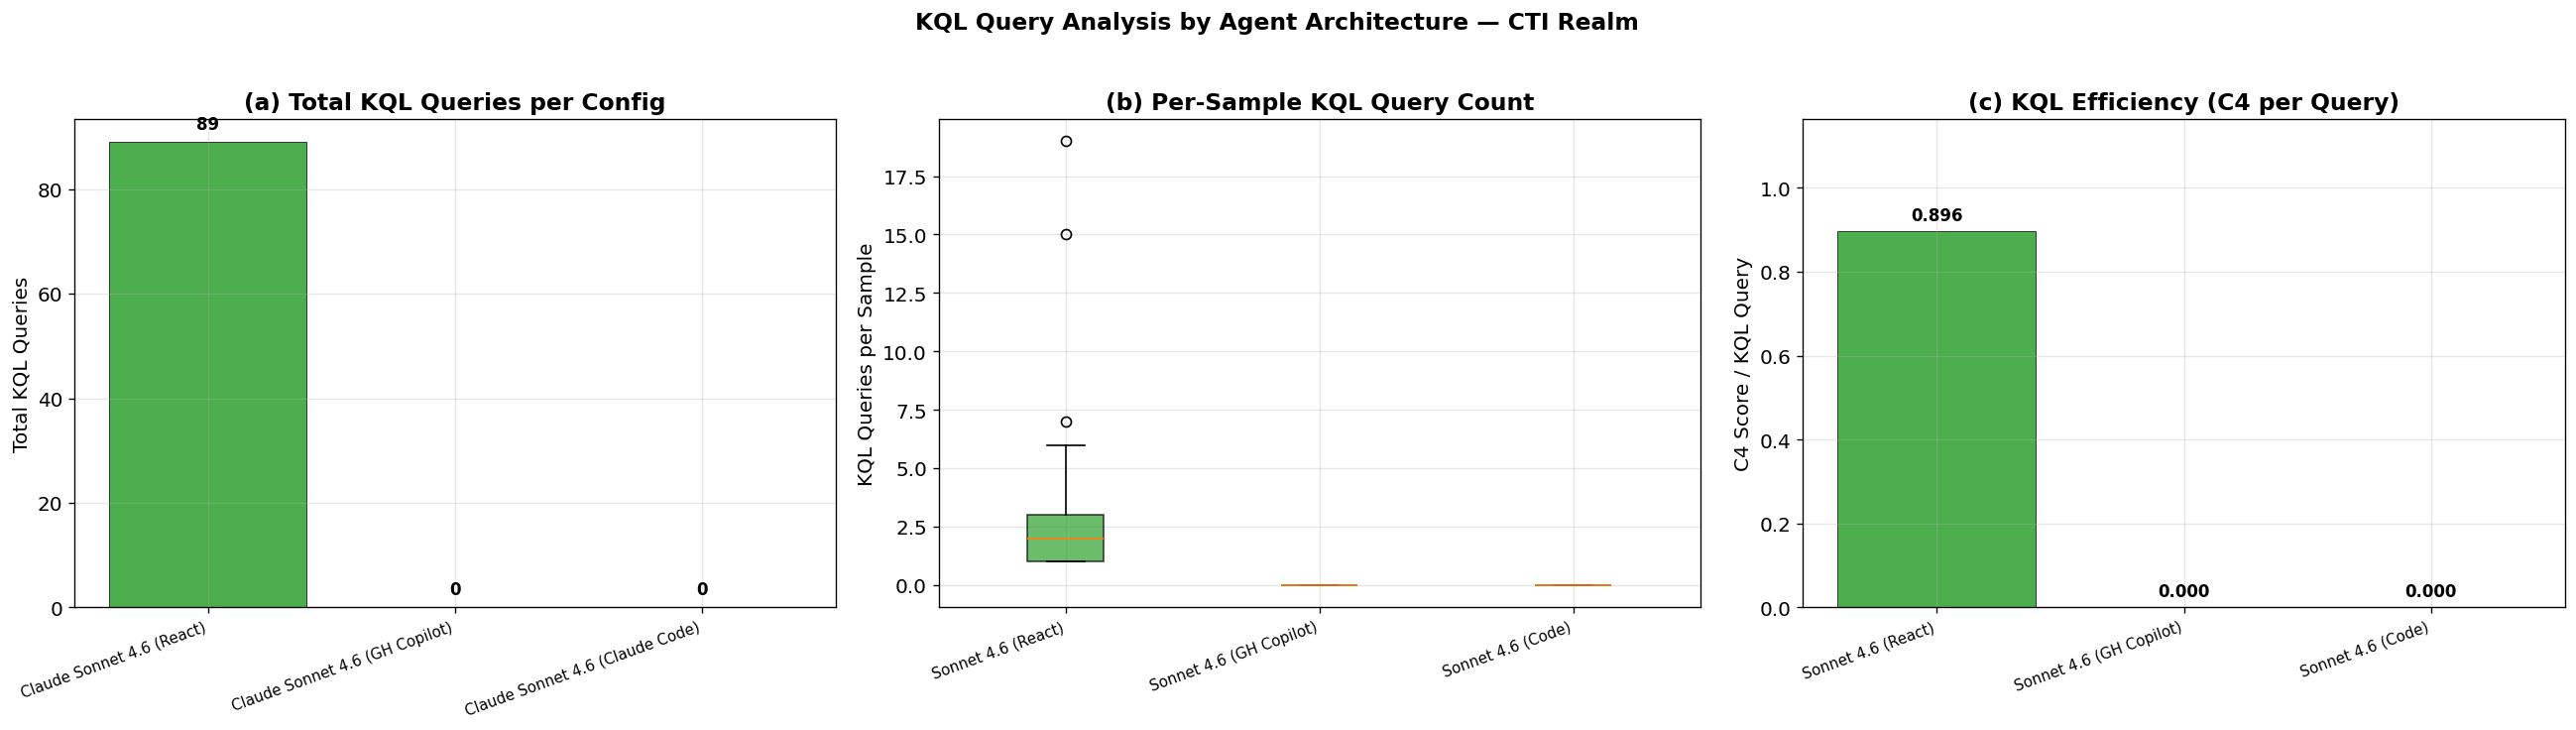


KQL Efficiency Summary:
Config                               Total KQL  Mean/Sample  Mean C4   C4/Query
--------------------------------------------------------------------------------
Claude Sonnet 4.6 (React)                   89          3.6     3.19      0.896
Claude Sonnet 4.6 (GH Copilot)               0          0.0     1.04      0.000
Claude Sonnet 4.6 (Claude Code)              0          0.0     1.06      0.000


In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 3: KQL Query Quality Analysis by Agent Architecture
# ══════════════════════════════════════════════════════════════════════════════
kql_records = []
for m in active_traj:
    mdf = traj_df[traj_df['model'] == m]
    for _, row in mdf.iterrows():
        n_kql = int(row.get('tool_execute_kql_query', 0))
        kql_records.append({
            'model': m, 'sample_id': row['sample_id'],
            'n_kql_total': n_kql,
        })

kql_df = pd.DataFrame(kql_records)
kql_df = kql_df.merge(c4_lookup, on=['model', 'sample_id'], how='left')

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# (a) Total KQL queries per config
ax = axes[0]
x = np.arange(len(active_traj))
totals = [kql_df[kql_df['model'] == m]['n_kql_total'].sum() for m in active_traj]
for i, (m, t) in enumerate(zip(active_traj, totals)):
    ax.bar(i, t, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, t + max(totals)*0.02, str(t), ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(active_traj, fontsize=9, rotation=20, ha='right')
ax.set_ylabel('Total KQL Queries')
ax.set_title('(a) Total KQL Queries per Config', fontweight='bold')

# (b) Per-sample box plot
ax = axes[1]
bp_data = [kql_df[kql_df['model'] == m]['n_kql_total'].values for m in active_traj]
bp = ax.boxplot(bp_data, labels=[m.replace('Claude ', '').replace('GPT-', 'GPT') for m in active_traj],
                patch_artist=True)
for patch, m in zip(bp['boxes'], active_traj):
    patch.set_facecolor(COLORS[m]); patch.set_alpha(0.7)
ax.set_ylabel('KQL Queries per Sample')
ax.set_title('(b) Per-Sample KQL Query Count', fontweight='bold')
ax.set_xticklabels([m.replace('Claude ', '').replace('GPT-', 'GPT') for m in active_traj],
                    fontsize=9, rotation=20, ha='right')

# (c) KQL efficiency: C4 score per KQL query
ax = axes[2]
efficiencies = []
for m in active_traj:
    mdf = kql_df[kql_df['model'] == m]
    mean_kql = mdf['n_kql_total'].mean()
    mean_c4 = mdf['c4_score'].mean() if 'c4_score' in mdf.columns else 0
    eff = mean_c4 / mean_kql if mean_kql > 0 else 0
    efficiencies.append(eff)
for i, (m, eff) in enumerate(zip(active_traj, efficiencies)):
    ax.bar(i, eff, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, eff + max(efficiencies)*0.02, f'{eff:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_xticks(range(len(active_traj)))
ax.set_xticklabels([m.replace('Claude ', '').replace('GPT-', 'GPT') for m in active_traj],
                    fontsize=9, rotation=20, ha='right')
ax.set_ylabel('C4 Score / KQL Query')
ax.set_title('(c) KQL Efficiency (C4 per Query)', fontweight='bold')
ax.set_ylim(0, max(efficiencies) * 1.3 if efficiencies else 1)

fig.suptitle(f'KQL Query Analysis by Agent Architecture — {DOMAIN_NAME}', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'kql_analysis_by_agent.png', bbox_inches='tight')
plt.show()

# Summary
print('\nKQL Efficiency Summary:')
print(f'{"Config":35s} {"Total KQL":>10s} {"Mean/Sample":>12s} {"Mean C4":>8s} {"C4/Query":>10s}')
print('-' * 80)
for m, eff in zip(active_traj, efficiencies):
    mdf = kql_df[kql_df['model'] == m]
    mean_kql = mdf['n_kql_total'].mean()
    mean_c4 = mdf['c4_score'].mean() if 'c4_score' in mdf.columns else 0
    print(f'{m:35s} {mdf["n_kql_total"].sum():10d} {mean_kql:12.1f} {mean_c4:8.2f} {eff:10.3f}')

---

## 4. Checkpoint Correlation by Agent Architecture

### What this measures

Compares **checkpoint interdependencies** across agent architectures using Spearman rank correlation. Key questions:

- Do checkpoint relationships change with agent architecture?
- Does one architecture produce more aligned checkpoint performance (higher inter-checkpoint correlation)?
- Is the C2 ↔ C4 relationship (data exploration → detection quality) stronger for some architectures?

### How to read the chart

- One correlation matrix per agent config — compare patterns across panels
- Red = positive correlation, blue = negative
- Consistent patterns across agents = intrinsic task property; different patterns = architecture effect

/tmp/ipykernel_66174/1742432090.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])


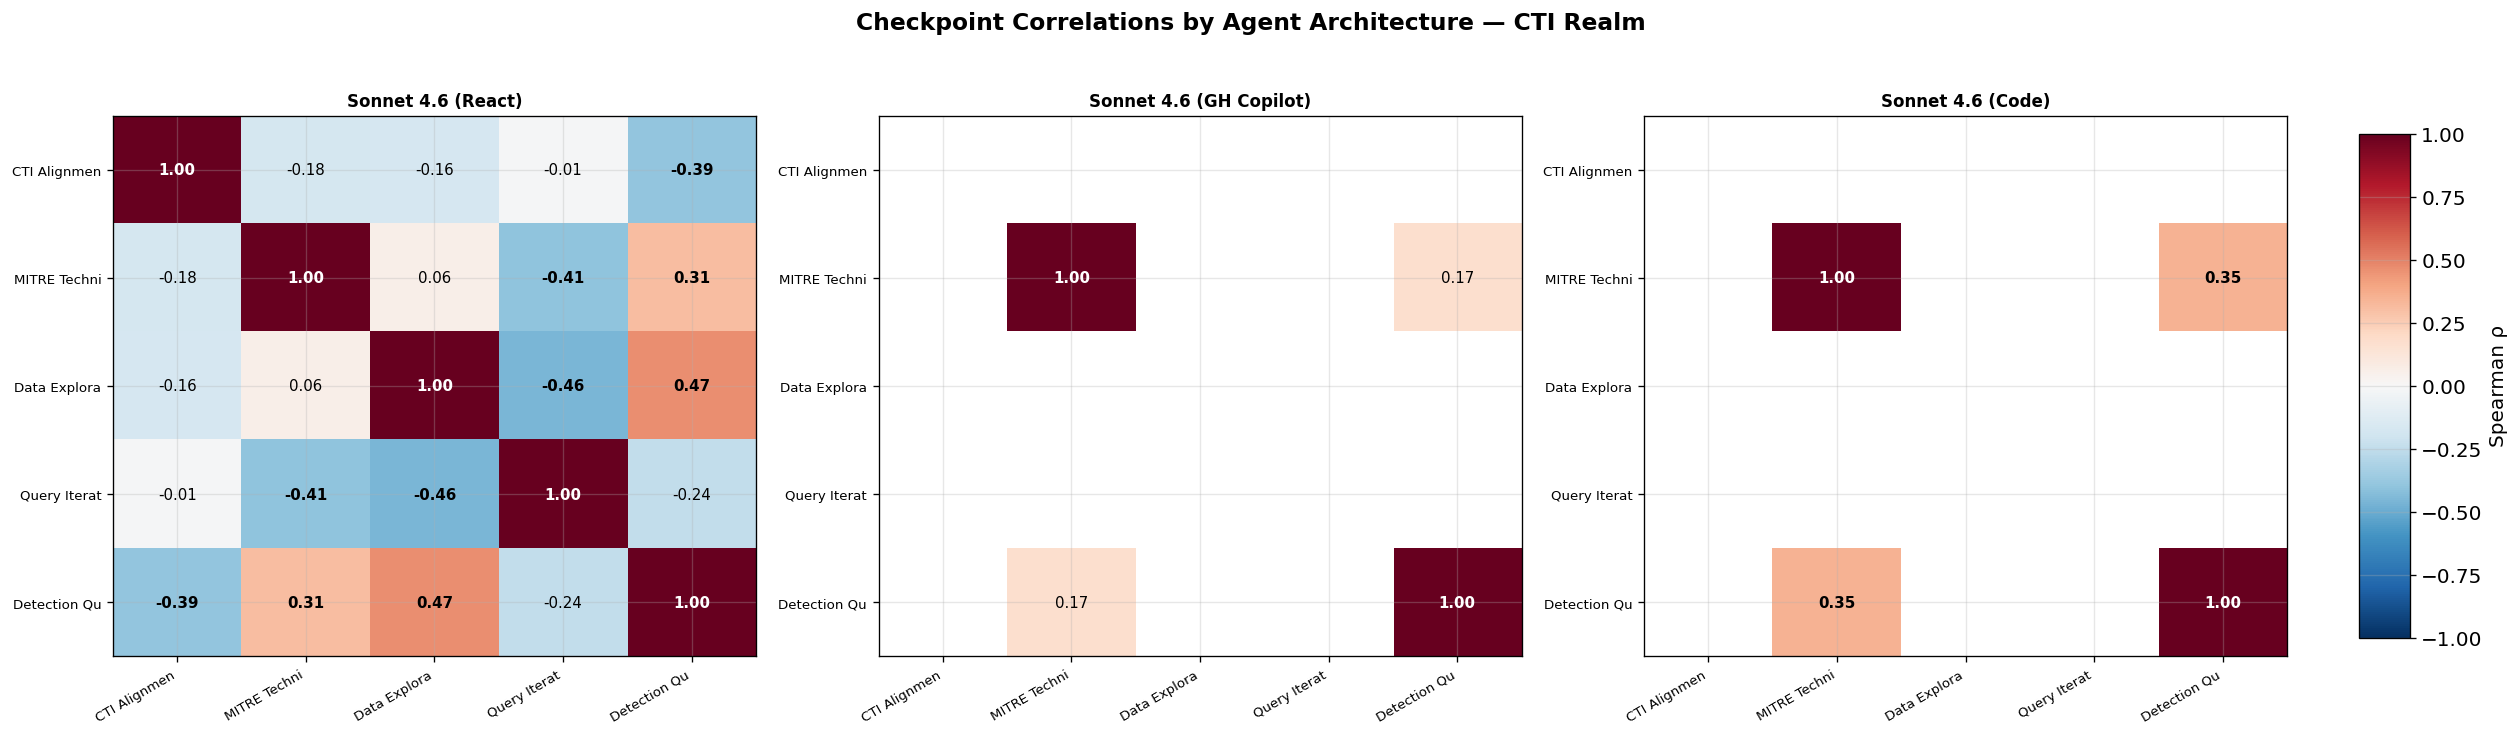


Key Checkpoint Correlations by Agent Config:
Config                                C0↔C4   C2↔C4   C1↔C4   C0↔C1
----------------------------------------------------------------------
Claude Sonnet 4.6 (React)           -0.393  +0.468  +0.305  -0.180
Claude Sonnet 4.6 (GH Copilot)      +nan  +nan  +0.165  +nan
Claude Sonnet 4.6 (Claude Code)     +nan  +nan  +0.347  +nan


/tmp/ipykernel_66174/1742432090.py:85: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(valid[c1], valid[c2])
/tmp/ipykernel_66174/1742432090.py:85: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(valid[c1], valid[c2])
/tmp/ipykernel_66174/1742432090.py:85: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(valid[c1], valid[c2])
/tmp/ipykernel_66174/1742432090.py:85: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(valid[c1], valid[c2])
/tmp/ipykernel_66174/1742432090.py:85: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(valid[c1], valid[c2])
/tmp/ipykernel_66174/1742432090.py:85: ConstantInputWarning: An input array is constant; the correlation coefficient is 

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 4: Checkpoint Correlation by Agent Architecture
# ══════════════════════════════════════════════════════════════════════════════
from scipy.stats import spearmanr

checkpoints = list(CHECKPOINT_NAMES.keys())
active_configs = [m for m in MODEL_ORDER if m in model_overall]
n_configs = len(active_configs)

fig, axes = plt.subplots(1, n_configs, figsize=(7 * n_configs, 6), squeeze=False)

for idx, m in enumerate(active_configs):
    ax = axes[0, idx]

    # Build checkpoint score matrix for this config
    m_sub = subtasks_df[subtasks_df['model'] == m]
    ckpt_records = []
    for sid in m_sub['sample_id'].unique():
        row = {'sample_id': sid}
        sid_sub = m_sub[m_sub['sample_id'] == sid]
        for ck in checkpoints:
            ck_scores = sid_sub[sid_sub['score_type'] == ck]['score']
            row[ck] = ck_scores.values[0] if len(ck_scores) > 0 else np.nan
        ckpt_records.append(row)
    ckpt_config_df = pd.DataFrame(ckpt_records)

    # Spearman correlation
    corr = ckpt_config_df[checkpoints].corr(method='spearman')

    labels = [CHECKPOINT_NAMES[ck].split(': ')[1][:12] for ck in checkpoints]
    im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(checkpoints)))
    ax.set_xticklabels(labels, fontsize=8, rotation=30, ha='right')
    ax.set_yticks(range(len(checkpoints)))
    ax.set_yticklabels(labels, fontsize=8)

    for i in range(len(checkpoints)):
        for j in range(len(checkpoints)):
            val = corr.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9,
                        fontweight='bold' if abs(val) > 0.3 else 'normal',
                        color='white' if abs(val) > 0.6 else 'black')

    short = m.replace('Claude ', '').replace('GPT-', 'GPT')
    ax.set_title(short, fontweight='bold', fontsize=10)

# Add single colorbar
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Spearman ρ')

fig.suptitle(f'Checkpoint Correlations by Agent Architecture — {DOMAIN_NAME}',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.savefig(ARTIFACTS_DIR / 'checkpoint_correlations_by_agent.png', bbox_inches='tight')
plt.show()

# Key correlation comparison
print('\nKey Checkpoint Correlations by Agent Config:')
print(f'{"Config":35s} {"C0↔C4":>7s} {"C2↔C4":>7s} {"C1↔C4":>7s} {"C0↔C1":>7s}')
print('-' * 70)
for m in active_configs:
    m_sub = subtasks_df[subtasks_df['model'] == m]
    ckpt_records = []
    for sid in m_sub['sample_id'].unique():
        row = {}
        sid_sub = m_sub[m_sub['sample_id'] == sid]
        for ck in checkpoints:
            ck_scores = sid_sub[sid_sub['score_type'] == ck]['score']
            row[ck] = ck_scores.values[0] if len(ck_scores) > 0 else np.nan
        ckpt_records.append(row)
    df = pd.DataFrame(ckpt_records)

    pairs = [
        ('c0_cti_analysis', 'c4_detection_quality'),
        ('c2_data_exploration', 'c4_detection_quality'),
        ('c1_mitre_techniques', 'c4_detection_quality'),
        ('c0_cti_analysis', 'c1_mitre_techniques'),
    ]
    vals = []
    for c1, c2 in pairs:
        valid = df[[c1, c2]].dropna()
        if len(valid) > 2:
            rho, _ = spearmanr(valid[c1], valid[c2])
            vals.append(f'{rho:+.3f}')
        else:
            vals.append('  n/a')
    print(f'{m:35s} {"  ".join(vals)}')

---

## Next Steps

### Companion notebooks

- Run the **domain-agnostic** [`agent_architecture_analysis.ipynb`](agent_architecture_analysis.ipynb) for overall score comparisons, cost analysis, tool usage, and trajectory analysis across agent architectures (Experiments 1–12).
- See [`cti_realm_analysis.ipynb`](cti_realm_analysis.ipynb) for model-comparison analysis in the CTI Realm domain (without the agent architecture dimension).

### Extending this analysis

1. After more agent evaluations complete (e.g., more models × agents), re-run for richer comparisons
2. Compare checkpoint heatmaps to identify which agent architectures best support specific CTI skills
3. Investigate KQL query patterns to understand how architecture affects investigation strategy
4. Cross-reference with the domain-agnostic notebook for cost and efficiency layering

### Data loading notes

All log parsing uses **inspect_ai's typed log API**:
- `read_eval_log(header_only=True)` for run-level results and stats
- `read_eval_log_sample_summaries()` for per-sample scores, timing, and model usage
- `read_eval_log_sample(id=...)` for full message/tool-call detail per sample